In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from os.path import join as pjoin
import csv
from scipy.optimize import minimize
import re

import processing_fun
importlib.reload(processing_fun)

from utils import OperonArgs

In [2]:
def round_sigfigs(values, sigfigs):
    values = np.asarray(values, dtype=float)

    if sigfigs <= 0:
        raise ValueError("sigfigs must be greater than 0")

    result = np.zeros_like(values)
    nonzero = values != 0

    mags = np.floor(np.log10(np.abs(values[nonzero])))
    factors = 10 ** (sigfigs - 1 - mags)

    result[nonzero] = np.round(values[nonzero] * factors) / factors
    return result

# Distribution of Parameters

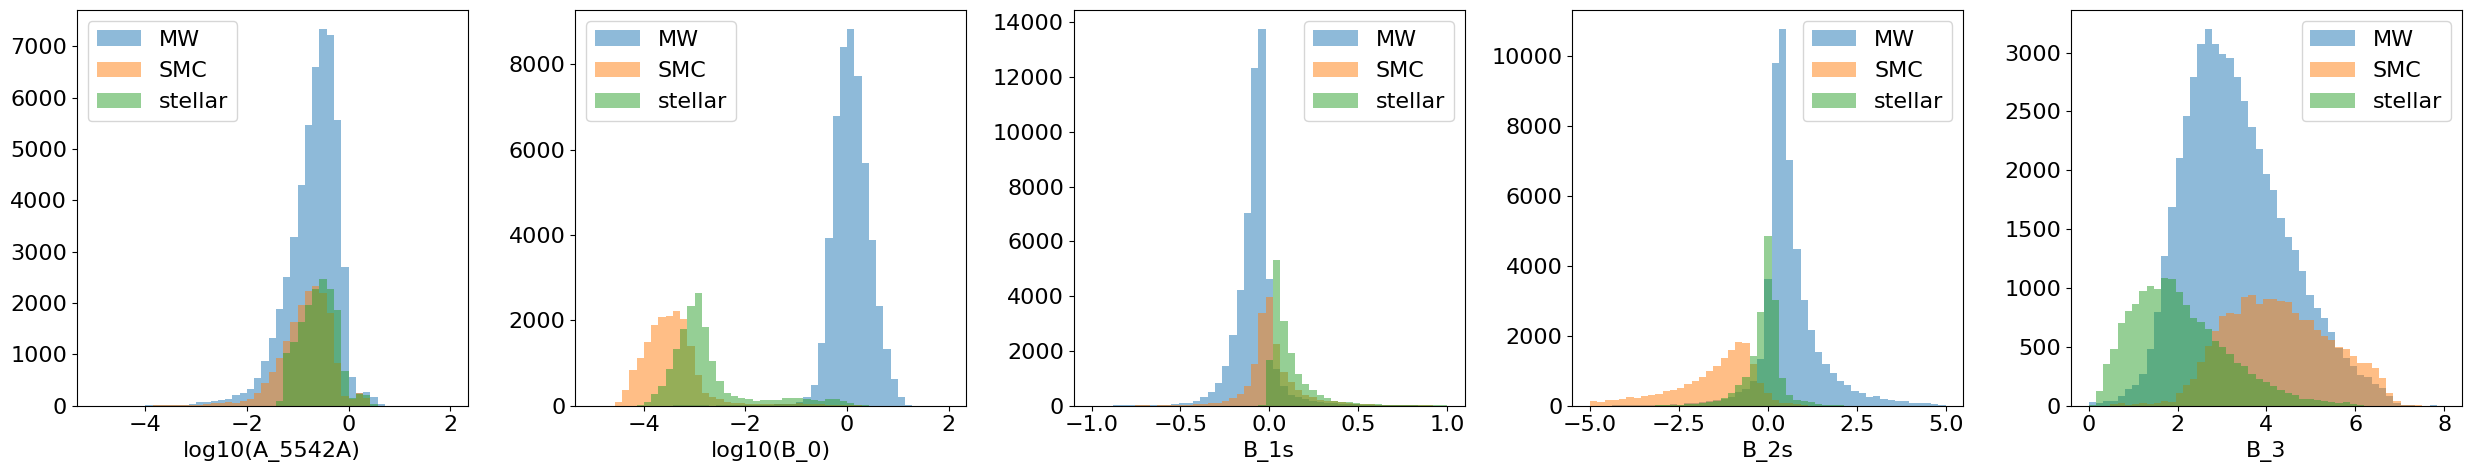

In [63]:
fname = 'fits/B_0_13/B_0_train_10.csv'
ytrue, ypred = np.loadtxt(fname, usecols=(-2, -1), unpack=True)
# plt.hist(np.log10(ytrue), bins=50);

bins = np.linspace(-5, 2, 50)

keep_cols = ['A_5542A', 'B_0', 'B_1s', 'B_2s', 'B_3']
do_log = [True, True, False, False, False]
all_bins = [np.linspace(-5, 2, 50), np.linspace(-5, 2, 50), np.linspace(-1, 1, 50), np.linspace(-5, 5, 50), np.linspace(0, 8, 50)]

fig, axs = plt.subplots(1, len(keep_cols), figsize=(5*len(keep_cols), 5))

for dust_mixture in ['MW', 'SMC', 'stellar']:
    if dust_mixture == 'MW':
        fname = f'/mnt/users/deaglan/symbolic_regression/iob-attenuation/data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust_mixture}_los09.dat'
    else:
        fname = f'/mnt/users/deaglan/symbolic_regression/iob-attenuation/data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust_mixture}_all.dat'

    out_lines = []
    with open(fname, "r") as fh:
        header = next(fh)
        # Remove any part of header between square brackets, as this is not a valid column name and causes problems for pandas
        header = re.sub(r'\[.*?\]', '', header)
    header = header.strip().split()
    # Only load column B0
    df = pd.read_csv(fname, sep=r'\s+', names=header, comment='#', low_memory=False, skiprows=1, usecols=keep_cols)

    for ax, col, log, bins in zip(axs, keep_cols, do_log, all_bins):
        values = df[col].values
        values = values[np.isfinite(values)]
        if log:
            values = values[values > 0]
            values = np.log10(values)
        ax.hist(values, bins=bins, alpha=0.5, label=dust_mixture, histtype='stepfilled')
        if log:
            ax.set_xlabel(f'log10({col})')
        else:
            ax.set_xlabel(col)
        ax.legend()
fig.tight_layout()

galaxy_id	los	IOB1	IOB2	IOB3	IOB4	IOB5	IOB6	IOB7	IOB8	A_1516A	A_1588A	A_1663A	A_1742A	A_1825A	A_1911A	A_2002A	A_2097A	A_2196A	A_2300A	A_2409A	A_2523A	A_2643A	A_2768A	A_2899A	A_3036A	A_3180A	A_3331A	A_3489A	A_3654A	A_3827A	A_4008A	A_4198A	A_4397A	A_4605A	A_4824A	A_5052A	A_5291A	A_5542A	A_5805A	A_6080A	A_6368A	A_6669A	A_6985A	A_7316A	A_7663A	A_8026A	A_8406A	A_8804A	A_9221A	A_9658A	galaxy_id_prop	logMstar [Msun]	logMgas [Msun]	SFR [Msun/yr]	SFR_compact [Msun/yr]	Zgas [mass fraction]	Rstar [kpc]	Rgas [kpc]	logMdust [Msun]	Sigma_SFR [Msun/yr/kpc^2]	sSFR [1/yr]	inclination_deg	B_0	B_1s	B_2s	B_3



0.8826138252933331 1.1519933562752673e-05 22.545943022495564
galaxy_id	los	IOB1	IOB2	IOB3	IOB4	IOB5	IOB6	IOB7	IOB8	A_1516A	A_1588A	A_1663A	A_1742A	A_1825A	A_1911A	A_2002A	A_2097A	A_2196A	A_2300A	A_2409A	A_2523A	A_2643A	A_2768A	A_2899A	A_3036A	A_3180A	A_3331A	A_3489A	A_3654A	A_3827A	A_4008A	A_4198A	A_4397A	A_4605A	A_4824A	A_5052A	A_5291A	A_5542A	A_5805A	A_6080A	A_6368A	A_6669A	A_6985A	A_7316A	A_7663A	A_8026A	A_8406A	A_8804A	A_9221A	A_9658A	galaxy_id_prop	logMstar [Msun]	logMgas [Msun]	SFR [Msun/yr]	SFR_compact [Msun/yr]	Zgas [mass fraction]	Rstar [kpc]	Rgas [kpc]	logMdust [Msun]	Sigma_SFR [Msun/yr/kpc^2]	sSFR [1/yr]	inclination_deg	B_0	B_1s	B_2s	B_3

0.9949684128540847 9.576307165743889e-05 9.496879633816848
galaxy_id	los	IOB1	IOB2	IOB3	IOB4	IOB5	IOB6	IOB7	IOB8	A_1260A	A_1320A	A_1382A	A_1448A	A_1516A	A_1588A	A_1663A	A_1742A	A_1825A	A_1911A	A_2002A	A_2097A	A_2196A	A_2300A	A_2409A	A_2523A	A_2643A	A_2768A	A_2899A	A_3036A	A_3180A	A_3331A	A_3489A	A_3654A	A_3827A	A_4008A	A_4198A	A_4397A	A_460

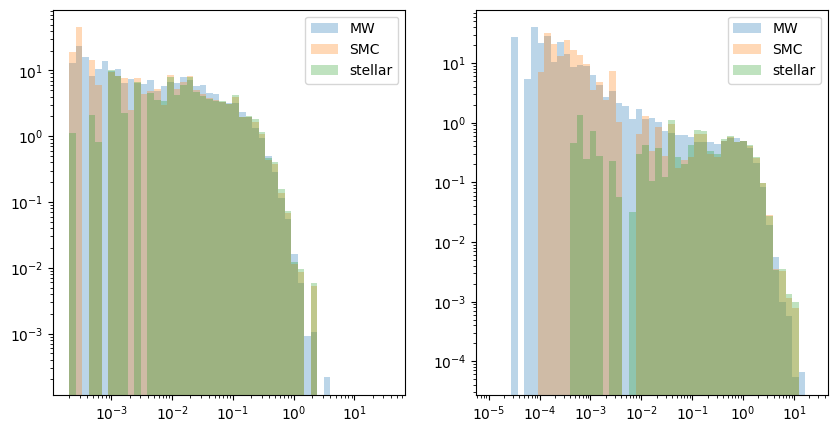

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

keep_cols = ['logMstar', 'SFR', 'sSFR']

# SFR [Msun/yr]
# logMstar [Msun]
# sSFR [yr^-1]
# New sSFR in units 1e10 yr^-1

bins_old = None
bins_new = None

for dust_mixture in ['MW', 'SMC', 'stellar']:
    if dust_mixture == 'MW':
        fname = f'/mnt/users/deaglan/symbolic_regression/iob-attenuation/data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust_mixture}_los09.dat'
    else:
        fname = f'/mnt/users/deaglan/symbolic_regression/iob-attenuation/data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust_mixture}_all.dat'

    out_lines = []
    with open(fname, "r") as fh:
        header = next(fh)
        print(header)
        # Remove any part of header between square brackets, as this is not a valid column name and causes problems for pandas
        header = re.sub(r'\[.*?\]', '', header)
    header = header.strip().split()
    df = pd.read_csv(fname, sep=r'\s+', names=header, comment='#', low_memory=False, skiprows=1, usecols=keep_cols) 

    new_sSFR = df['SFR'].values / 10.**df['logMstar'].values * 1e10
    print(np.median(new_sSFR), np.min(new_sSFR[new_sSFR > 0]), np.max(new_sSFR))

    if bins_old is None:
        bins_old = np.logspace(np.log10(np.min(df['SFR'].values[df['SFR'].values > 0])), np.log10(np.max(df['SFR'].values)), 50)
    if bins_new is None:
        bins_new = np.logspace(np.log10(np.min(new_sSFR[new_sSFR > 0])), np.log10(np.max(new_sSFR)), 50)

    axs[0].hist(df['sSFR'].values, label=dust_mixture, alpha=0.3, bins=bins_old, histtype='stepfilled', log=True, density=True)
    axs[1].hist(new_sSFR, label=dust_mixture, alpha=0.3, bins=bins_new, histtype='stepfilled', log=True, density=True)

for ax in axs:
    ax.set_xscale('log')
    ax.legend()

# Av

Searching for a function of galaxy properties which is agnostic to dust mixture

Test if Av is exact or inferred

In [ ]:
fname = '../data/merged_bestfit_galprops_SMC.dat'
df_fit = pd.read_csv(fname, sep=r'\s+', usecols=["#galaxy_id", "los", "Av"])
df_fit.rename(columns={'#galaxy_id': 'galaxy_id'}, inplace=True)

fname = '../data/gal_los_iobcomp_attcurve_galprop_29_01_SMC.dat'
df_data = pd.read_csv(fname, sep=r'\s+', usecols=["galaxy_id", "los", "A_5542A"])

# Merge the two dataframes on galaxy_id and los
df_merged = pd.merge(df_fit, df_data, on=['galaxy_id', 'los'])

# See if the two equal
print(np.all(df_merged['Av'] == df_merged['A_5542A']))

Operon fits


Reading from configuration file: conf/Av_13.ini
Reading from selection file: conf/selection_21.ini

All model lengths:
[ 5  6  7  8  9 10 11 13 14 16 17 18 19 20 21 22 24]

Equation requested:
((-4.581131) + (1.559633 * (((((0.871366 * X11) ^ 9.562682) - ((673.039307 * X9) ^ ((-5.425620) * X6))) - (2.203832 * X1)) + log((150.101913 * X1)))))


100%|██████████| 17/17 [00:00<00:00, 155.80it/s]


Latex version:
- b_{0} f + b_{1} \log{\left(b_{2} f \right)} + b_{3} \sin^{b_{4}}{\left(i \right)} - b_{5} - b_{6} \left(\Sigma_{SFR} b_{7}\right)^{- Z_{gas} b_{8}}

Number of parameters: 9
Values: [3.437169113656, 1.559633, 150.101913, 0.418003450197906, 9.562682, 4.581131, 1.559633, 673.039307, 5.42562]

1 - R2 for chosen model:
Training: 0.3805
Validation: 0.3454

R2 for chosen model:
Training: 0.6195
Validation: 0.6546

Reading from configuration file: conf/Av_13.ini
Reading from selection file: conf/selection_21.ini
fits/Av_13/Av_train_16.csv
True range: -1.2998936321084646 0.42148283395204866
fits/Av_13/Av_val_16.csv
True range: -1.2970441471958003 0.4531447404832081


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'log10(Av): Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'log10(Av): Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

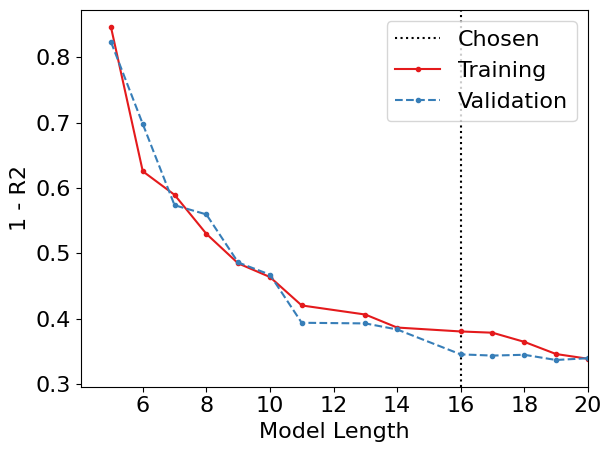

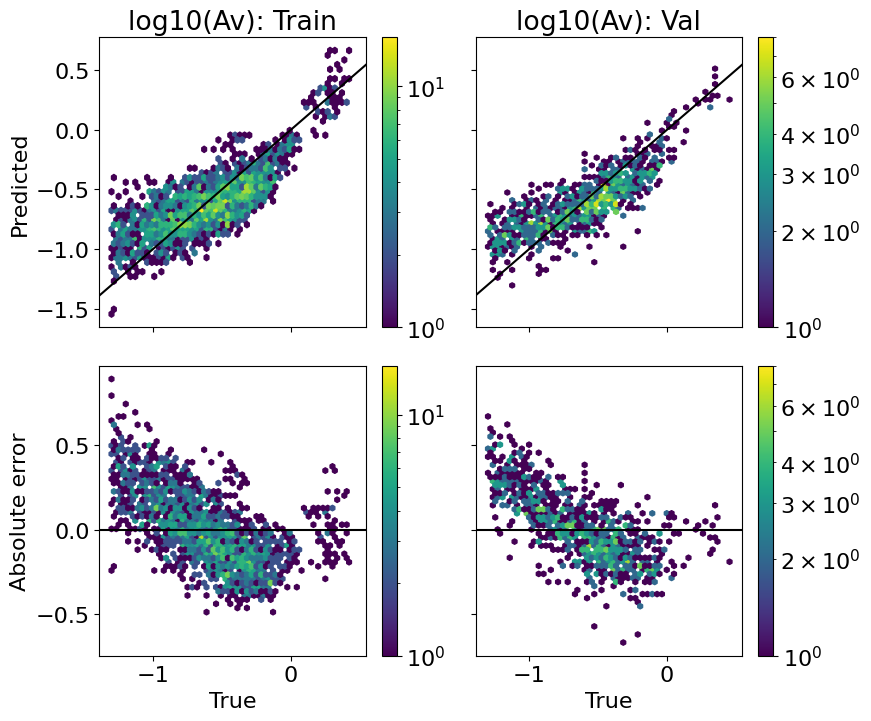

In [ ]:
# --------------------------------------------------------
# These models include SFR_compact as a feature

ini_file = 'conf/Av_0.ini'; ilen = 17
ini_file = 'conf/Av_1.ini'; ilen = 13
ini_file = 'conf/Av_2.ini'; ilen = 14
ini_file = 'conf/Av_3.ini'; ilen = 11

# --------------------------------------------------------
# These models do not include SFR_compact as a feature

ini_file = 'conf/Av_4.ini'; ilen = 13
ini_file = 'conf/Av_5.ini'; ilen = 15

# --------------------------------------------------------
# These models do not include SFR_compact as a feature
# and depend on dust mixture parameters

ini_file = 'conf/Av_6.ini'; ilen = 16
ini_file = 'conf/Av_7.ini'; ilen = 17
ini_file = 'conf/Av_8.ini'; ilen = 18
# ini_file = 'conf/Av_9.ini'; ilen = 18

# --------------------------------------------------------
# Now also don't have Mdust
ini_file = 'conf/Av_10.ini'; ilen = 13
# ini_file = 'conf/Av_11.ini'; ilen = 13

# --------------------------------------------------------
# Correct sSFR - No improvement from previous results
ini_file = 'conf/Av_12.ini'; ilen = 15
ini_file = 'conf/Av_13.ini'; ilen = 16

# Av_4; ilen=13
# Training: 0.6128
# Validation: 0.6234

# Av_6; ilen=16
# Training: 0.6195
# Validation: 0.6546

# Av_7; ilen=16
# Training: 0.6238
# Validation: 0.6586

# Av_7; ilen=19
# Training: 0.6593
# Validation: 0.6690

# CAVEAT: Validation contains some bad LOS for MW dust

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)


Reading from configuration file: conf/Av_6.ini
Reading from selection file: conf/selection_16.ini
fits/Av_6/Av_train_16.csv
fits/Av_6/Av_6_names.txt
['dust_mixture', 'galaxy_id_prop', 'logMstar', 'logMgas', 'SFR', 'Zgas', 'Rstar', 'Rgas', 'logMdust', 'Sigma_SFR', 'sSFR', 'inclination_sin', 'true', 'pred']
(2000, 14)
[3.59134197e+00 3.43731209e+00 4.17999374e-01 9.56274600e+00
 3.23493274e+00 1.55970000e+00 6.72890381e+02 5.42475000e+00]
Initial R2: 0.6195160177404643
True
[5.27329615e+00 4.98459015e+00 4.20142215e-01 9.63111226e+00
 4.51466874e+00 1.50820148e+00 6.45515956e+02 5.69751361e+00]
Final R2: 0.6239276054894591
[5.27, 4.98, 0.42, 9.63, 4.51, 1.51, 646.0, 5.7]
Rounded R2 (train): 0.624
Rounded R2 (validation): 0.659


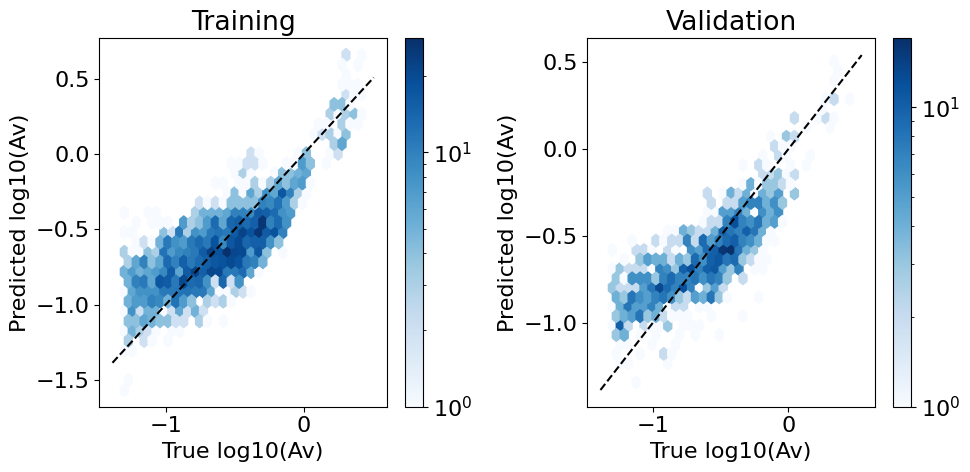

In [50]:
ini_file = 'conf/Av_6.ini'
length = 16

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

b = [3.4373120913, 1.5597, 5.851458, 0.417999373728281, 9.562746, 0.479425, 1.5597, 672.890381, 5.42475]
c = np.empty(8)
c[0] = b[1] * np.log(10)
c[1] = b[0]
c[2] = b[3]
c[3] = b[4]
c[4] = b[5] + b[1] * np.log(b[2])
c[5] = b[6]
c[6] = b[7]
c[7] = b[8]
print(c)

def mypred(c, data=df):
    f = data['dust_mixture']
    Sigma_SFR = data['Sigma_SFR']
    sini = data['inclination_sin']
    Zgas = data['Zgas']
    pred = c[0] * np.log10(f) - c[1] * f + c[2] * sini ** c[3] + c[4] - c[5] * (c[6] * Sigma_SFR)**(-c[7] * Zgas) 
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()


Reading from configuration file: conf/Av_7.ini
Reading from selection file: conf/selection_16.ini
fits/Av_7/Av_train_17.csv
fits/Av_7/Av_7_names.txt
['dust_mixture', 'galaxy_id_prop', 'logMstar', 'logMgas', 'SFR', 'Zgas', 'Rstar', 'Rgas', 'logMdust', 'Sigma_SFR', 'sSFR', 'inclination_sin', 'true', 'pred']
(2000, 14)
Initial R2: 0.05501143029351363


False
[4.27922407e-01 9.67338441e-03 9.52847995e-01 3.82981864e-03
 1.50746898e+00 1.68141949e+00 8.00419341e+02 4.74632478e+00]
Final R2: 0.614907603203546
[0.428, 0.00967, 0.953, 0.00383, 1.51, 1.68, 800.0, 4.75]
Rounded R2 (train): 0.615
Rounded R2 (validation): 0.650
Standard deviation of residuals: 0.221


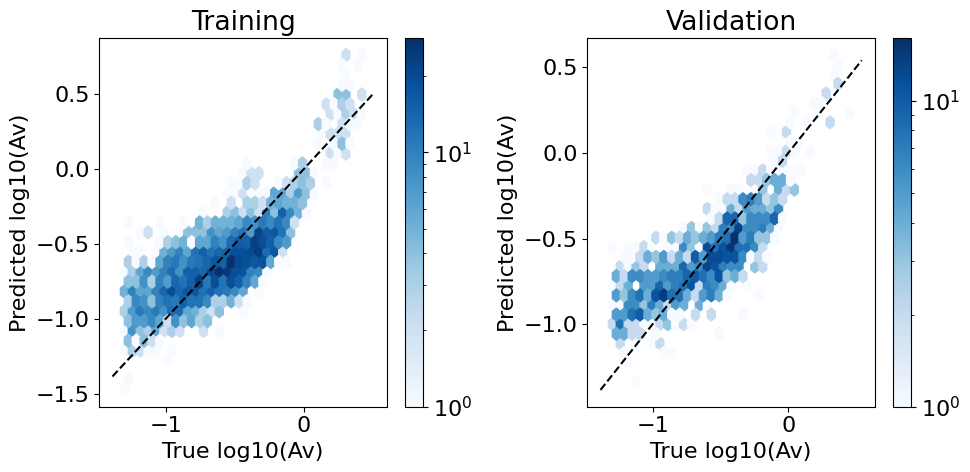

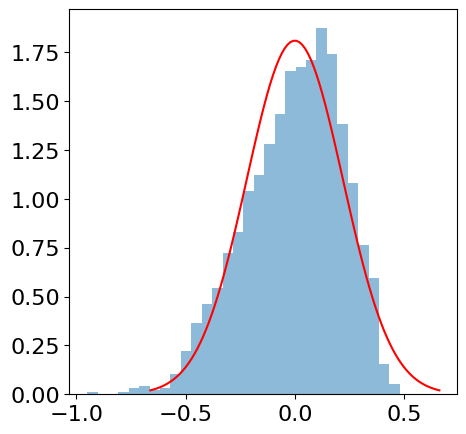

In [51]:
ini_file = 'conf/Av_7.ini'
length = 17

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

b = [0.006061439244, 0.915434, 0.196856, 0.008926682028, 1.526734, 1.511204, 631.582825, 5.612523]
c = np.empty(8)
c[0] = b[2]
c[1] = b[0] / np.log(10)
c[2] = b[1]
c[3] = b[3] / np.log(10)
c[4:] = b[4:]

def mypred(c, data=df):
    f = data['dust_mixture']
    Sigma_SFR = data['Sigma_SFR']
    sini = data['inclination_sin']
    Zgas = data['Zgas']
    logMdust = data['logMdust']
    pred = c[0] * np.log10(f) - c[1] * f + c[2] * sini ** c[3] + c[4] - c[5] * (c[6] * Sigma_SFR)**(-c[7] * Zgas) 
    # - \frac{b_{0} \operatorname{log}_{10}{\left(M_{dust} \right)}}{\log{\left(b_{1} \sin{\left(i \right)} \right)}} + b_{2} - \frac{b_{3}}{\log{\left(b_{4} f \right)}} - b_{5} \left(\Sigma_{SFR} b_{6}\right)^{- Z_{gas} b_{7}}
    # pred = c[0] - c[1] * logMdust / (np.log10(c[2] * sini)) - c[3] / np.log10(c[4] * f) - c[5] * (c[6] * Sigma_SFR)**(-c[7] * Zgas)
    pred = c[0] - c[1] / (np.log10(c[2] * sini)) - c[3] / np.log10(c[4] * f) - c[5] * (c[6] * Sigma_SFR)**(-c[7] * Zgas)
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()


fig, ax = plt.subplots(figsize=(5, 5))
residual = df['true'] - mypred(cnew, data=df)
sigma = np.std(residual)
ax.hist(residual, bins=30, alpha=0.5, density=True)
x = np.linspace(-3*sigma, 3*sigma, 100)
y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, y, 'r-')
print('Standard deviation of residuals: %.3f' % sigma)

# $B_0$

Searching for a function of other fit parameters specific to a given dust mixture

## MW dust


Reading from configuration file: conf/B0_9.ini
Reading from selection file: conf/selection_8.ini

All model lengths:
[ 5  6  7  9 10 12 13 15 17 18 19 20 21 23 24]

Equation requested:
((-0.000000) + (1.000000 * ((0.208719 * X2) - ((((((-0.868841) * X2) - ((23.531075 * X3) ^ (0.093368 * X2))) - (9.631482 * X1)) / ((-2.172734) * X2)) + ((-0.652170) * X1)))))


100%|██████████| 15/15 [00:00<00:00, 105.78it/s]

For val data, removing 43 of 957 points with true value < -0.5



Latex version:
B_{1s} b_{0} + B_{3} b_{1} + \frac{b_{2} \left(- B_{1s} b_{3} - B_{3} b_{4} - \left(A_{V} b_{5}\right)^{B_{3} b_{6}}\right)}{B_{3}}

Number of parameters: 7
Values: [0.65217, 0.208719, 0.460249620984437, 9.631482, 0.868841, 23.531075, 0.093368]

1 - R2 for chosen model:
Training: 0.0692
Validation: 0.0740

R2 for chosen model:
Training: 0.9308
Validation: 0.9260

Reading from configuration file: conf/B0_9.ini
Reading from selection file: conf/selection_8.ini
fits/B_0_9/B_0_train_17.csv
For train data, removing 48 of 1952 points with true value < -0.5
True range: -0.49826858125621454 0.9325134378982811
fits/B_0_9/B_0_val_17.csv
For val data, removing 43 of 957 points with true value < -0.5
True range: -0.49408254185528755 0.9813773409486618


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'log10(B_0): Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'log10(B_0): Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

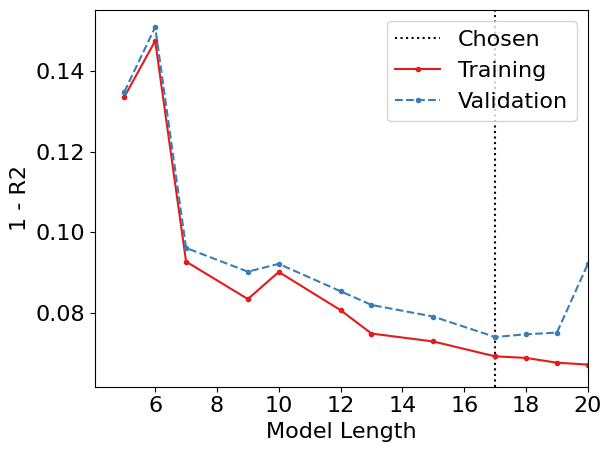

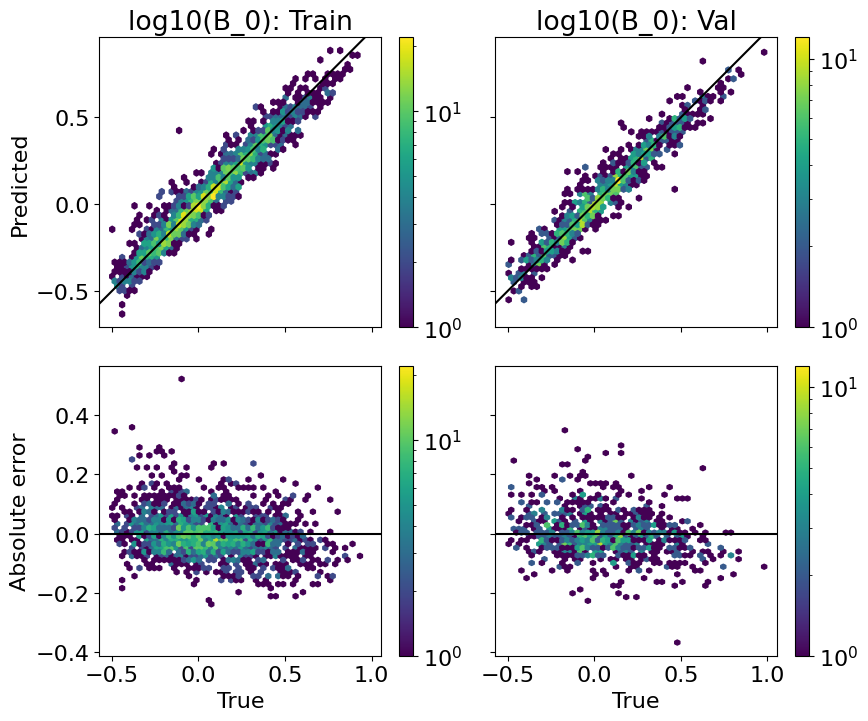

In [ ]:
ini_file = 'conf/B0_0.ini'; ilen = 18
ini_file = 'conf/B0_3.ini'; ilen = 18

# These runs don't depend on B2
ini_file = 'conf/B0_6.ini'; ilen = 15
ini_file = 'conf/B0_9.ini'; ilen = 17

# B0_9, ilen=17, min_true=-0.5
# Training: 0.9308
# Validation: 0.9260

# Very good results without needing to know B2

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0, min_true=-0.5)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False, min_true=-0.5)


Reading from configuration file: conf/B0_9.ini
Reading from selection file: conf/selection_8.ini
fits/B_0_9/B_0_train_17.csv
fits/B_0_9/B_0_9_names.txt
['B_1s', 'B_3', 'Av', 'true', 'pred']
(2000, 5)
[0.65217, 0.208719, 0.460249620984437, 9.631482, 0.868841, 23.531075, 0.093368]
Initial R2: 0.9307767347383968
False
[ 0.66160056  0.22360578  0.32735372 13.77590587  1.5304059  23.71018748
  0.11234881]
Final R2: 0.9314934195740159
[0.662, 0.224, 0.327, 13.8, 1.53, 23.7, 0.112]
Rounded R2 (train): 0.931
Rounded R2 (validation): 0.927
Standard deviation of residuals: 0.072


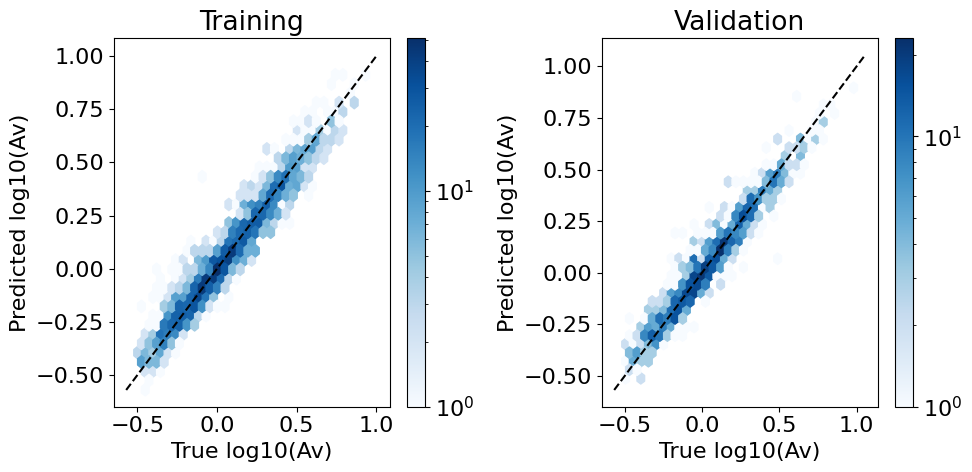

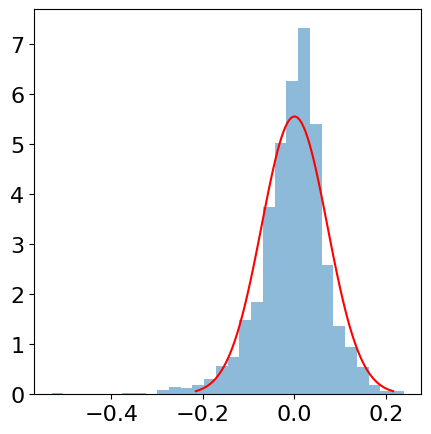

In [52]:
ini_file = 'conf/B0_9.ini'
length = 17
min_true = -0.5

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

# Cut the df to only include rows where true >= min_true
df = df[df['true'] >= min_true]
df_val = df_val[df_val['true'] >= min_true]

c = [0.65217, 0.208719, 0.460249620984437, 9.631482, 0.868841, 23.531075, 0.093368]
print(c)

def mypred(c, data=df):
    B1s = data['B_1s']
    B3 = data['B_3']
    Av = data['Av']
    pred = c[0] * B1s + c[1] * B3 - c[2] / B3 * (c[3] * B1s + c[4] * B3 + (c[5] * Av) ** (c[6] * B3))
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5, 5))
residual = df['true'] - mypred(cnew, data=df)
sigma = np.std(residual)
ax.hist(residual, bins=30, alpha=0.5, density=True)
x = np.linspace(-3*sigma, 3*sigma, 100)
y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, y, 'r-')
print('Standard deviation of residuals: %.3f' % sigma)

## SMC dust


Reading from configuration file: conf/B0_7.ini
Reading from selection file: conf/selection_9.ini

All model lengths:
[ 5  6  7  8  9 11 12 13 15 16 17 19 20 21 22 23 24]

Equation requested:
((-4.275409) + (3.505388 * ((0.174070 * X3) ^ 0.405209)))


100%|██████████| 17/17 [00:00<00:00, 187.59it/s]

For val data, removing 54 of 928 points with true value < -4
For val data, removing 18 of 928 points with true value > -2



Latex version:
A_{V}^{b_{1}} b_{0} - b_{2}

Number of parameters: 3
Values: [1.72611846450543, 0.405209, 4.275409]

1 - R2 for chosen model:
Training: 0.5117
Validation: 0.5991

R2 for chosen model:
Training: 0.4883
Validation: 0.4009

Reading from configuration file: conf/B0_7.ini
Reading from selection file: conf/selection_9.ini
fits/B_0_7/B_0_train_7.csv
For train data, removing 87 of 1913 points with true value < -4
For train data, removing 95 of 1818 points with true value > -2
True range: -4.0 -2.0112627247112
fits/B_0_7/B_0_val_7.csv
For val data, removing 54 of 946 points with true value < -4
For val data, removing 18 of 928 points with true value > -2
True range: -4.0 -2.0085081110898404


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'log10(B_0): Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'log10(B_0): Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

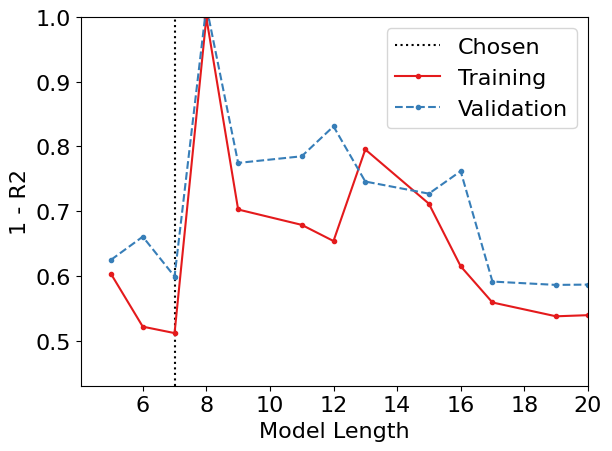

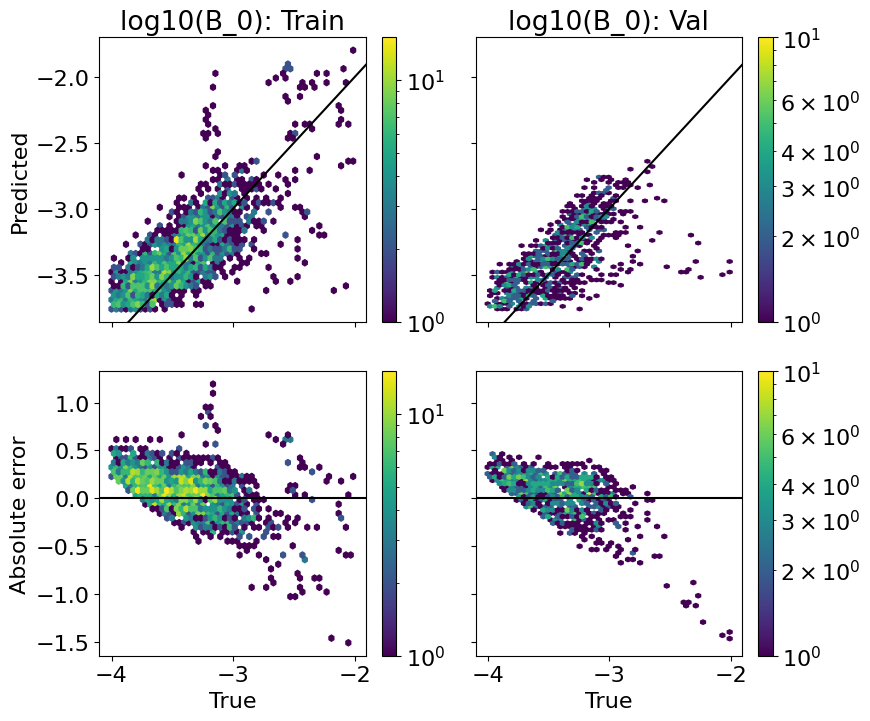

In [103]:
ini_file = 'conf/B0_1.ini'; ilen = 17
ini_file = 'conf/B0_4.ini'; ilen = 17

# These runs don't depend on B2
ini_file = 'conf/B0_7.ini'; ilen = 7
# ini_file = 'conf/B0_10.ini'; ilen = 6

# B0_1, ilen=17, min_true=-4, max_true=-2
# Training: 0.4899
# Validation: 0.5577

# B0_4, ilen=17, min_true=-4, max_true=-2
# Training: 0.4910
# Validation: 0.5588

# B0_7, ilen=7, min_true=-4, max_true=-2
# Training: 0.4883
# Validation: 0.4009

# B0_10, ilen=6, min_true=-4, max_true=-2
# Training: 0.4783
# Validation: 0.3393

# Some improvement if you know B2

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0, min_true=-4, max_true=-2)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False, min_true=-4, max_true=-2)


Reading from configuration file: conf/B0_7.ini
Reading from selection file: conf/selection_9.ini
fits/B_0_7/B_0_train_7.csv
fits/B_0_7/B_0_7_names.txt
['B_1s', 'B_3', 'Av', 'true', 'pred']
(2000, 5)
Initial R2: 0.48829856874903055


True
[2.49737289 0.18503177 5.27779384]
Final R2: 0.5608400238512307
[2.5, 0.185, 5.28]
Rounded R2 (train): 0.561
Rounded R2 (validation): 0.430


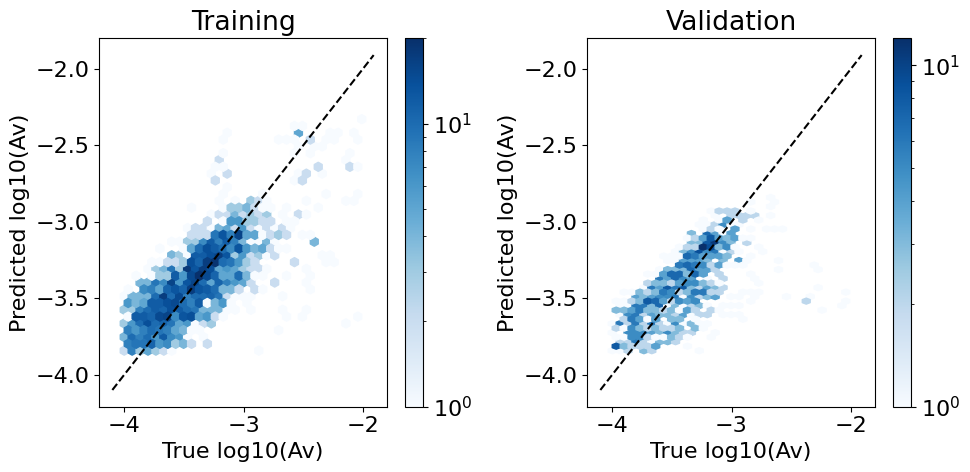

In [113]:
ini_file = 'conf/B0_7.ini'
length = 7
min_true = -4
max_true = -2

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

# Cut the df to only include rows where true >= min_true
df = df[df['true'] >= min_true]
df_val = df_val[df_val['true'] >= min_true]

# Also cut the df to only include rows where true <= max_true
df = df[df['true'] <= max_true]
df_val = df_val[df_val['true'] <= max_true]

c = [1.72611846450543, 0.405209, 4.275409]

def mypred(c, data=df):
    Av = data['Av']
    pred = c[0] * Av ** c[1] - c[2]
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

## Stellar dust


Reading from configuration file: conf/B0_11.ini
Reading from selection file: conf/selection_10.ini

All model lengths:
[ 5  6  7  9 10 11 12 13 15 17 19 21]

Equation requested:
((-9.965303) + (7.125517 * ((((0.195616 * X2) + (2.129335 * X3)) ^ (0.071557 * X2)) ^ (0.453880 * X2))))


100%|██████████| 12/12 [00:00<00:00, 102.04it/s]


Latex version:
b_{0} \left(\left(A_{V} b_{1} + B_{3} b_{2}\right)^{B_{3} b_{3}}\right)^{B_{3} b_{4}} - b_{5}

Number of parameters: 6
Values: [7.125517, 2.129335, 0.195616, 0.071557, 0.45388, 9.965303]

1 - R2 for chosen model:
Training: 0.5525
Validation: 0.6669

R2 for chosen model:
Training: 0.4475
Validation: 0.3331

Reading from configuration file: conf/B0_11.ini
Reading from selection file: conf/selection_10.ini
fits/B_0_11/B_0_train_11.csv
True range: -4.080921907623926 0.32734626302129877
fits/B_0_11/B_0_val_11.csv
True range: -3.958607314841775 0.11256344667948341


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'log10(B_0): Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'log10(B_0): Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

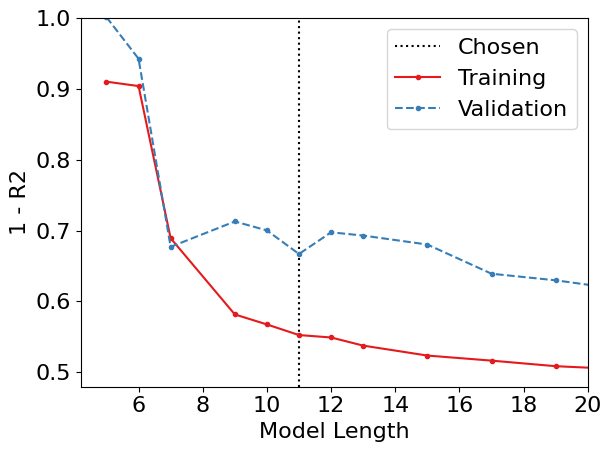

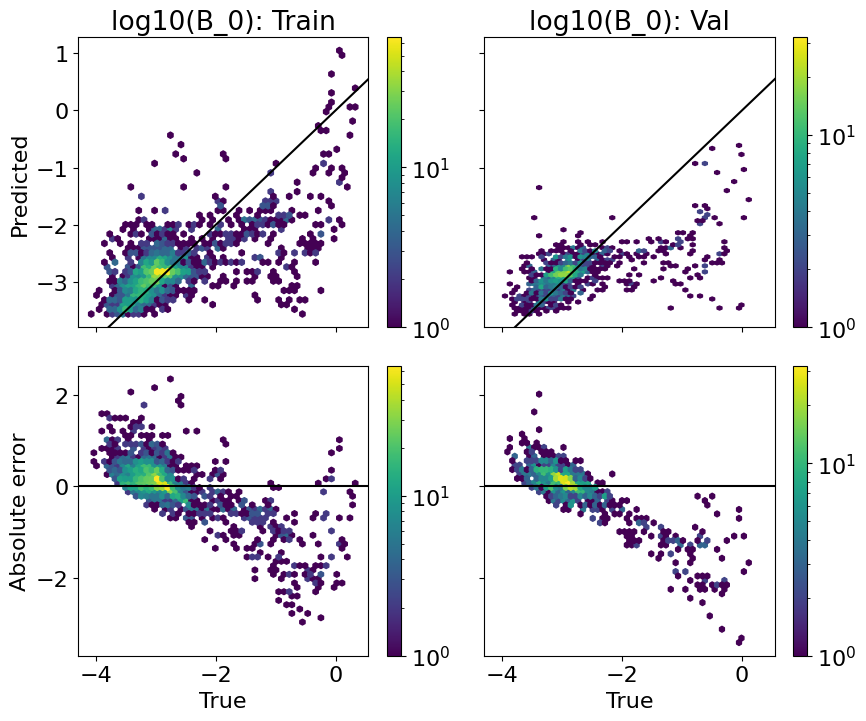

In [126]:
ini_file = 'conf/B0_2.ini'; ilen = 7
ini_file = 'conf/B0_5.ini'; ilen = 13

# These runs don't depend on B2
ini_file = 'conf/B0_8.ini'; ilen = 15
ini_file = 'conf/B0_11.ini'; ilen = 11

# B0_2, ilen=7
# Training: 0.3102
# Validation: 0.3286

# B0_5, ilen=13
# Training: 0.4769
# Validation: 0.3455

# B0_8, ilen=7
# Training: 0.3081
# Validation: 0.3305

# B0_11, ilen=7
# Training: 0.3108
# Validation: 0.3230

# Here might as well not use B2 - all quite similar

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)


Reading from configuration file: conf/B0_11.ini
Reading from selection file: conf/selection_10.ini
fits/B_0_11/B_0_train_11.csv
fits/B_0_11/B_0_11_names.txt
['B_1s', 'B_3', 'Av', 'true', 'pred']
(2000, 5)
[7.125517   2.129335   0.195616   0.03247829 9.965303  ]
Initial R2: 0.44752155675140903


True
[ 7.36742624  2.12536076  0.19600309  0.03145813 10.20728952]
Final R2: 0.44752550788937295
[7.37, 2.13, 0.196, 0.0315, 10.2]
Rounded R2 (train): 0.447
Rounded R2 (validation): 0.336


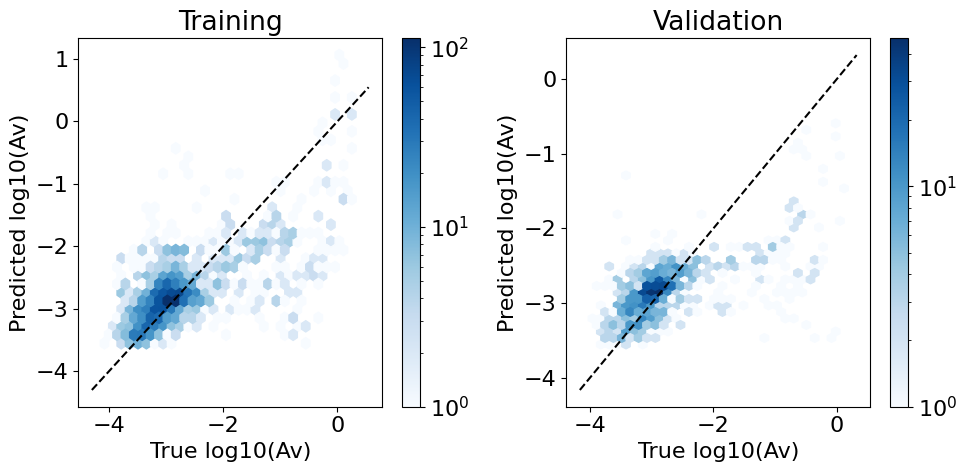

In [128]:
ini_file = 'conf/B0_11.ini'
length = 11

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

# # Cut the df to only include rows where true >= min_true
# df = df[df['true'] >= min_true]
# df_val = df_val[df_val['true'] >= min_true]

# # Also cut the df to only include rows where true <= max_true
# df = df[df['true'] <= max_true]
# df_val = df_val[df_val['true'] <= max_true]

b = [7.125517, 2.129335, 0.195616, 0.071557, 0.45388, 9.965303]
c = np.empty(5)
c[:3] = b[:3]
c[3] = b[3] * b[4]
c[4] = b[5]
print(c)

def mypred(c, data=df):
    Av = data['Av']
    B3 = data['B_3']
    pred = c[0] * (c[1] * Av + c[2] * B3) ** (c[3] * B3**2) - c[4]
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

## Mixed dust


Reading from configuration file: conf/B0_13.ini
Reading from selection file: conf/selection_13.ini

All model lengths:
[ 5  7  9 11 12 13 14 15 16 17 18 19 20 22 24]

Equation requested:
((-3.340375) + (1.011930 * ((((1.677357 * X1) ^ (0.394138 * X4)) + (-1.007858)) / (log((1.670686 * X1)) * ((1.552770 * X1) ^ (0.969930 * X3))))))


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 117.32it/s]

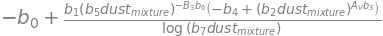


Latex version:
- b_{0} + \frac{b_{1} \left(b_{5} dust_{mixture}\right)^{- B_{3} b_{6}} \left(- b_{4} + \left(b_{2} dust_{mixture}\right)^{A_{V} b_{3}}\right)}{\log{\left(b_{7} dust_{mixture} \right)}}

Number of parameters: 8
Values: [3.340375, 1.01193, 1.677357, 0.394138, 1.007858, 1.55277, 0.96993, 1.670686]

1 - R2 for chosen model:
Training: 0.1076
Validation: 0.0785

R2 for chosen model:
Training: 0.8924
Validation: 0.9215

Reading from configuration file: conf/B0_13.ini
Reading from selection file: conf/selection_13.ini
fits/B_0_13/B_0_train_16.csv
True range: -4.346787486224656 0.7999073817640965
fits/B_0_13/B_0_val_16.csv
True range: -4.356547323513813 0.7860911761113123


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'log10(B_0): Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'log10(B_0): Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

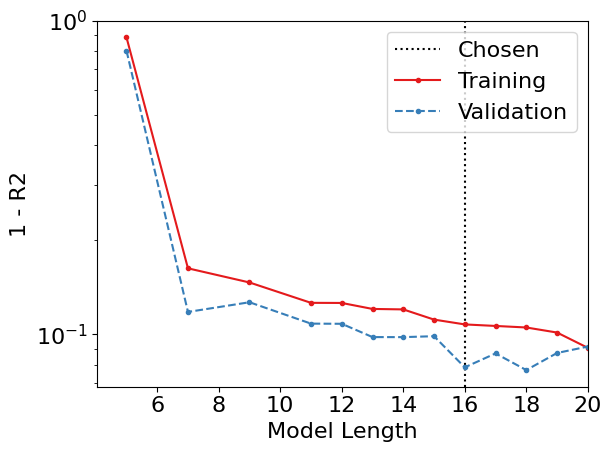

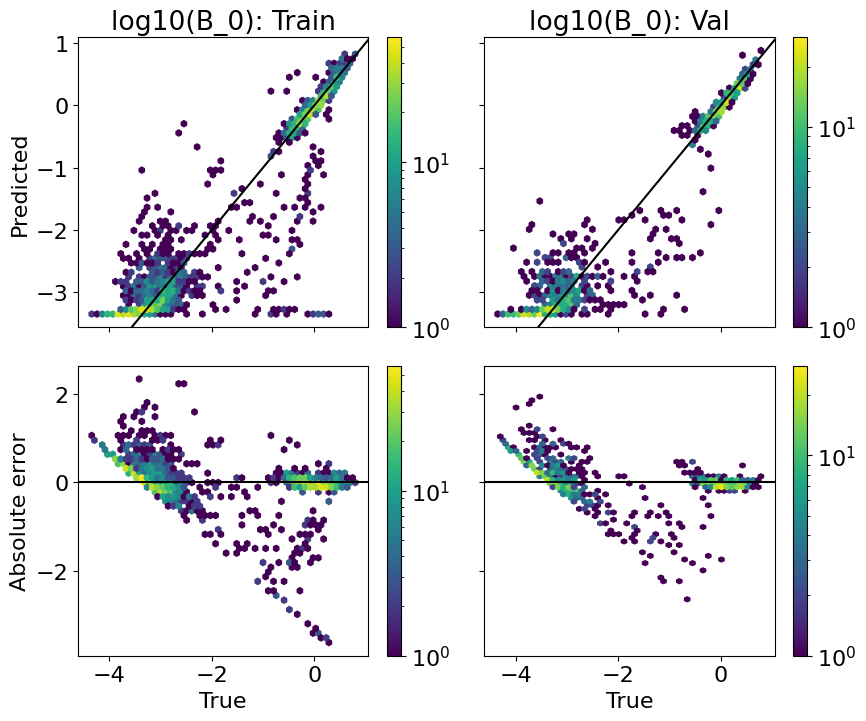

In [ ]:
# These runs don't depend on B2
ini_file = 'conf/B0_12.ini'; ilen = 7
ini_file = 'conf/B0_13.ini'; ilen = 16

# These runs do depend on B2
# ini_file = 'conf/B0_14.ini'; ilen = 19
# ini_file = 'conf/B0_15.ini'; ilen = 18

# Get such weird mixtures of dust parameters that it probably
# is best to have a different function per dust mixture

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='log', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False, log_target=False)

# SMC + Stellar Combined


Reading from configuration file: conf/B0_17.ini
Reading from selection file: conf/selection_19.ini

All model lengths:
[ 5  6  7  9 11 13 15 16 18 20 21 23]

Equation requested:
((-2.932011) + ((-143.645126) * (((-0.001112) * X3) * ((((0.497224 * X1) ^ ((-0.186542) * X3)) + ((7.309420 * X4) ^ (4.770197 * X2))) + ((2.453808 * X4) - log((23.947590 * X3)))))))


100%|██████████| 12/12 [00:00<00:00, 132.76it/s]



Latex version:
B_{3} b_{0} \left(A_{V} b_{1} + \left(A_{V} b_{2}\right)^{B_{1s} b_{3}} - \log{\left(B_{3} b_{4} \right)} + \left(b_{5} f\right)^{- B_{3} b_{6}}\right) - b_{7}

Number of parameters: 8
Values: [0.159733380112, 2.453808, 7.30942, 4.770197, 23.94759, 0.497224, 0.186542, 2.932011]

1 - R2 for chosen model:
Training: 0.3761
Validation: 0.5410

R2 for chosen model:
Training: 0.6239
Validation: 0.4590

Reading from configuration file: conf/B0_17.ini
Reading from selection file: conf/selection_19.ini
fits/B_0_17/B_0_train_18.csv
True range: -4.346787486224656 0.32734626302129877
fits/B_0_17/B_0_val_18.csv
True range: -4.267606240177032 0.157383019455605


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'log10(B_0): Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'log10(B_0): Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

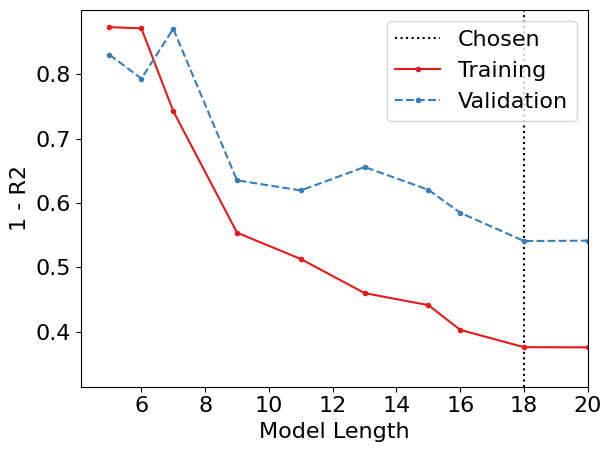

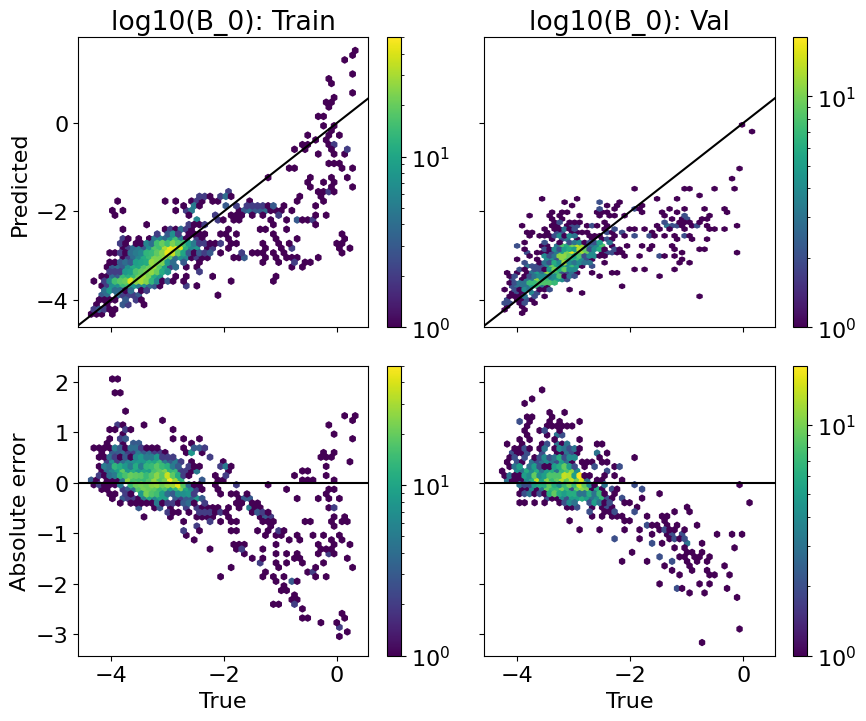

In [ ]:
max_true = None

# These runs don't depend on B2
ini_file = 'conf/B0_16.ini'; ilen = 17
ini_file = 'conf/B0_17.ini'; ilen = 18

# These runs do depend on B2
# ini_file = 'conf/B0_18.ini'; ilen = None
# ini_file = 'conf/B0_19.ini'; ilen = 17

# B0_16.ini'; ilen = 17
# Training: 0.6215
# Validation: 0.4680

# B0_17.ini'; ilen = 18
# Training: 0.6239
# Validation: 0.4590

# B0_18.ini'; ilen = None
# Training: 0.6799
# Validation: 0.3901

# B0_19.ini'; ilen = 17
# Training: 0.6148
# Validation: 0.4461

# No significant improvement from knowing B2, so let's not use it

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0, max_true=max_true)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False, log_target=False, max_true=max_true)


Reading from configuration file: conf/B0_17.ini
Reading from selection file: conf/selection_19.ini
fits/B_0_17/B_0_train_18.csv
fits/B_0_17/B_0_17_names.txt
['dust_mixture', 'B_1s', 'B_3', 'Av', 'true', 'pred']
(2000, 6)
Initial R2: 0.3811334406975614
True
[ 0.04132382  5.79084967 10.20394665  3.77630422  5.12780299  7.20313401
  0.37933005  0.12714222  2.91372822]
Final R2: 0.7125519172072603
[0.0413, 5.79, 10.2, 3.78, 5.13, 7.2, 0.379, 0.127, 2.91]
Rounded R2 (train): 0.712
Rounded R2 (validation): 0.632
Standard deviation of residuals: 0.216


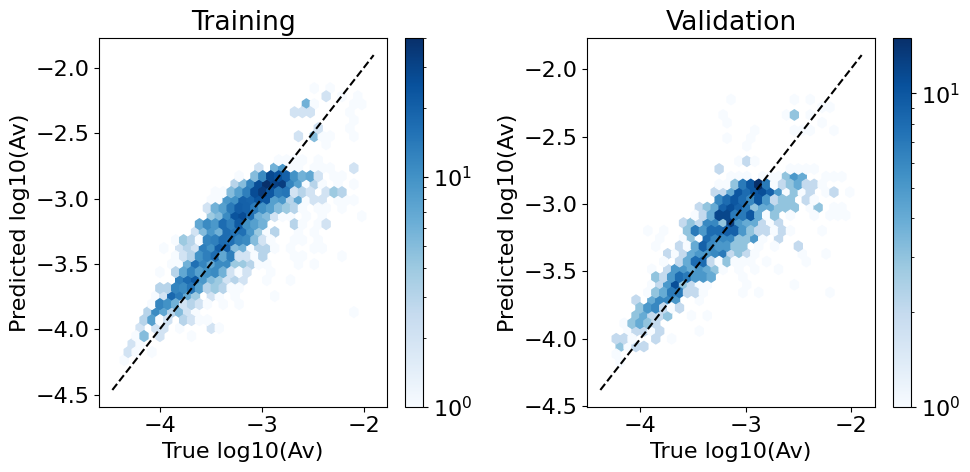

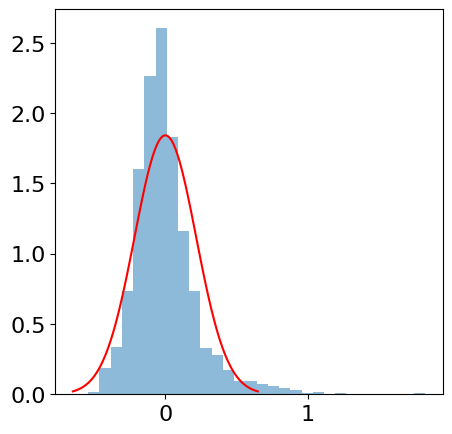

In [53]:
ini_file = 'conf/B0_17.ini'
length = 18
max_true = -2

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

# # Cut the df to only include rows where true >= min_true
# df = df[df['true'] >= min_true]
# df_val = df_val[df_val['true'] >= min_true]

# Also cut the df to only include rows where true <= max_true
df = df[df['true'] <= max_true]
df_val = df_val[df_val['true'] <= max_true]

b = [0.159733380112, 2.453808, 7.30942, 4.770197, 23.94759, 0.497224, 0.186542, 2.932011]
c = np.empty(9)
c[:4] = b[:4]
c[4] = np.log(10)
c[5:] = b[4:]

def mypred(c, data=df):
    Av = data['Av']
    B3 = data['B_3']
    B1s = data['B_1s']
    f = data['dust_mixture']
    pred = c[0] * B3 * (c[1] * Av + (c[2] * Av)**(c[3]*B1s) - c[4] * np.log10(c[5] * B3) + (c[6] * f)**(-c[7] * B3)) - c[8]
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead', options={'maxiter': 10000, 'maxfev': 10000})
print(res.success)
if not res.success:
    print(res.message)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5, 5))
residual = df['true'] - mypred(cnew, data=df)
sigma = np.std(residual)
ax.hist(residual, bins=30, alpha=0.5, density=True)
x = np.linspace(-3*sigma, 3*sigma, 100)
y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, y, 'r-')
print('Standard deviation of residuals: %.3f' % sigma)

# $B_1$

Searching for a function of galaxy properties and $A_{\rm V}$ which is agnostic to dust mixture


Reading from configuration file: conf/B1_12.ini
Reading from selection file: conf/selection_22.ini

All model lengths:
[ 5  6  7  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
((-0.000335) + ((-4.931436) * (((((-1.947687) * X1) + ((27.096806 * X6) ^ ((-5.817676) * X6))) + (log((1.825681 * X1)) + (0.063102 * X12))) * ((0.038587 * X11) ^ (0.959193 * X11)))))


  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:00<00:00, 158.34it/s]


Latex version:
- b_{0} \left(A_{V} b_{1}\right)^{A_{V} b_{2}} \left(- b_{3} f + b_{5} \sin{\left(i \right)} + \log{\left(b_{4} f \right)} + \left(Z_{gas} b_{6}\right)^{- Z_{gas} b_{7}}\right) - b_{8}

Number of parameters: 9
Values: [4.931436, 0.038587, 0.959193, 1.947687, 1.825681, 0.063102, 27.096806, 5.817676, 0.000335]

1 - R2 for chosen model:
Training: 0.4209
Validation: 0.4246

R2 for chosen model:
Training: 0.5791
Validation: 0.5754

Reading from configuration file: conf/B1_12.ini
Reading from selection file: conf/selection_22.ini
fits/B_1s_12/B_1s_train_18.csv
True range: -0.52613 1.306369
fits/B_1s_12/B_1s_val_18.csv
True range: -0.401454 0.823041


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'B_1s: Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'B_1s: Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

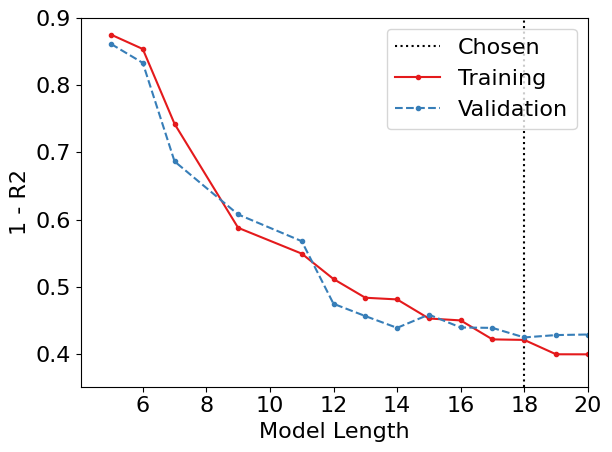

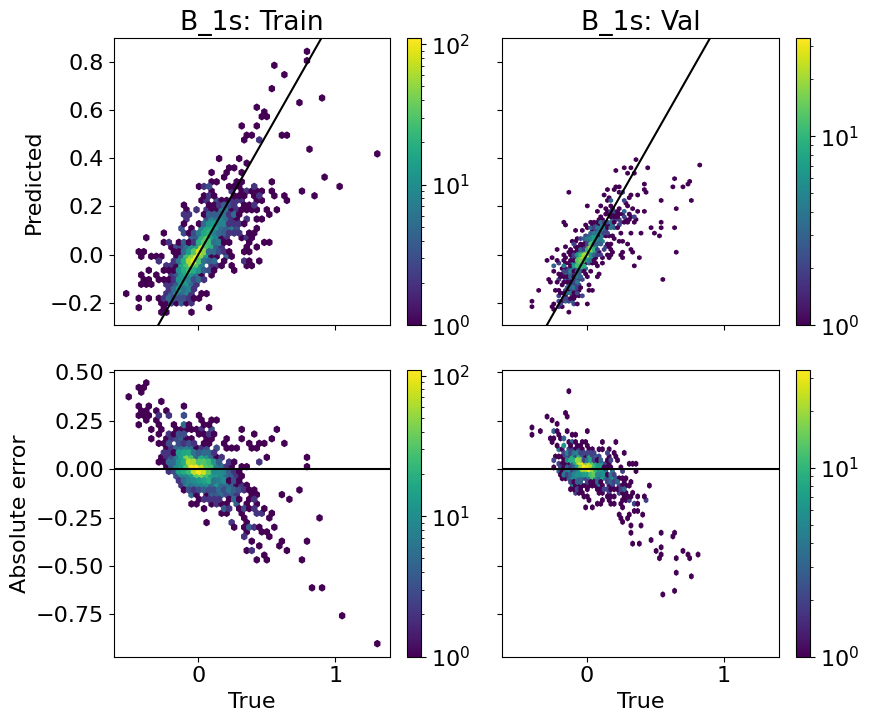

In [ ]:
# --------------------------------------------------------
# These models include SFR_compact as a feature

ini_file = 'conf/B1_0.ini'; ilen = 14
ini_file = 'conf/B1_1.ini'; ilen = 15
ini_file = 'conf/B1_2.ini'; ilen = 15

# --------------------------------------------------------
# These models do not include SFR_compact as a feature

ini_file = 'conf/B1_3.ini'; ilen = 7
# ini_file = 'conf/B1_4.ini'; ilen = 7

# --------------------------------------------------------
# These models do not include SFR_compact as a feature
# and depend on dust mixture parameters

# ini_file = 'conf/B1_5.ini'; ilen = 19
# ini_file = 'conf/B1_6.ini'; ilen = 17 # 17
ini_file = 'conf/B1_7.ini'; ilen = 16
# ini_file = 'conf/B1_8.ini'; ilen = 19

# --------------------------------------------------------
# Now also don't have Mdust
ini_file = 'conf/B1_9.ini'; ilen = 14 #14
# ini_file = 'conf/B1_10.ini'; ilen = 18

# Correct sSFR (cp of 9, 10) - no improvement from previous results
# ini_file = 'conf/B1_11.ini'; ilen = 17
ini_file = 'conf/B1_12.ini'; ilen = 18

# B1_5; ilen=17
# Training: 0.5833
# Validation: 0.5797

# B1_6; ilen=17
# Training: 0.5833
# Validation: 0.5801

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)


Reading from configuration file: conf/B1_6.ini
Reading from selection file: conf/selection_17.ini
fits/B_1s_6/B_1s_train_17.csv
fits/B_1s_6/B_1s_6_names.txt
['dust_mixture', 'galaxy_id_prop', 'logMstar', 'logMgas', 'SFR', 'Zgas', 'Rstar', 'Rgas', 'logMdust', 'Sigma_SFR', 'sSFR', 'Av', 'inclination_sin', 'true', 'pred']
(2000, 15)
[5.17064432 4.36711638 0.14727427 3.79797129 2.2455823  7.891761
 0.206298   0.644298  ]
Initial R2: 0.5805213541023162
False
[5.06744738 4.27292845 0.14296668 3.71186792 1.95550126 8.53707322
 0.20841806 0.63203038]
Final R2: 0.5829269354087333
[5.07, 4.27, 0.143, 3.71, 1.96, 8.54, 0.208, 0.632]
Rounded R2 (train): 0.583
Rounded R2 (validation): 0.584


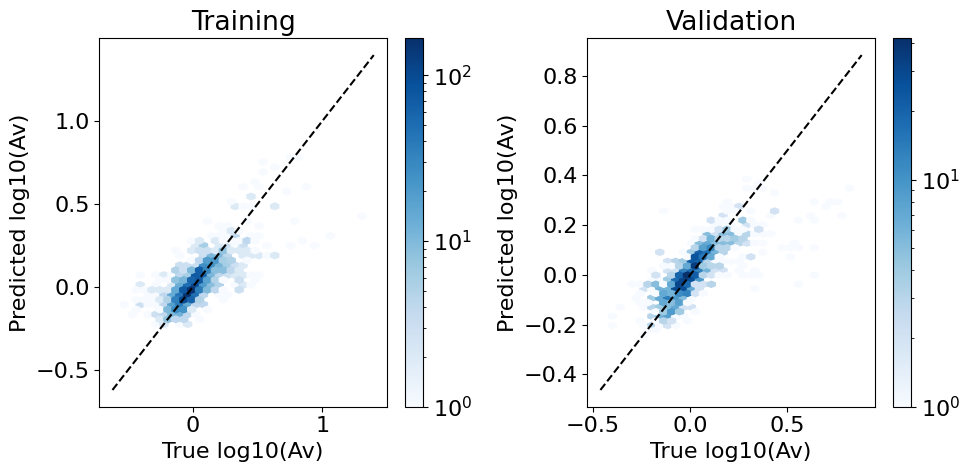

In [36]:
ini_file = 'conf/B1_6.ini'
length = 17

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

b = [0.975244, 1.944759, 7.891761, 0.206298, 5.426574, 0.065584, 0.644298, 0.007667]
c = np.empty(8)
c[0] = b[0] * np.log(10) ** 2
c[1] = b[0] * b[1] * np.log(10)
c[2] = b[0] * b[5] * np.log(10)
c[3] = b[0] * np.log(10) * np.log(b[4])
c[4] = b[0] * np.log(10)
c[5] = b[2]
c[6] = b[3]
c[7] = b[6]
print(c)

def mypred(c, data=df):
    f = data['dust_mixture']
    Zgas = data['Zgas']
    Av = data['Av']
    sini = data['inclination_sin']
    log10Mgas = data['logMgas']   
    pred = (c[0] * np.log10(f) - c[1] * f + c[2] * sini + c[3] - c[4] * (c[5] * Zgas) ** (c[6] * log10Mgas)) * np.log10(c[7] * Av)
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()


Reading from configuration file: conf/B1_9.ini
Reading from selection file: conf/selection_22.ini
fits/B_1s_9/B_1s_train_14.csv
fits/B_1s_9/B_1s_9_names.txt
['dust_mixture', 'galaxy_id_prop', 'logMstar', 'logMgas', 'SFR', 'Zgas', 'Rstar', 'Rgas', 'Sigma_SFR', 'sSFR', 'Av', 'inclination_sin', 'true', 'pred']
(2000, 14)
[3.24201660e-02 2.51270160e+01 2.44034000e+00 4.07107647e-03
 1.94281500e+00]
Initial R2: 0.5366404709332488
True
[3.23658068e-02 2.54981240e+01 2.36068503e+00 4.10892446e-03
 1.94774674e+00]
Final R2: 0.5374937634935276
[0.0324, 25.5, 2.36, 0.00411, 1.95]
Rounded R2 (train): 0.537
Rounded R2 (validation): 0.529
Standard deviation of residuals: 0.058


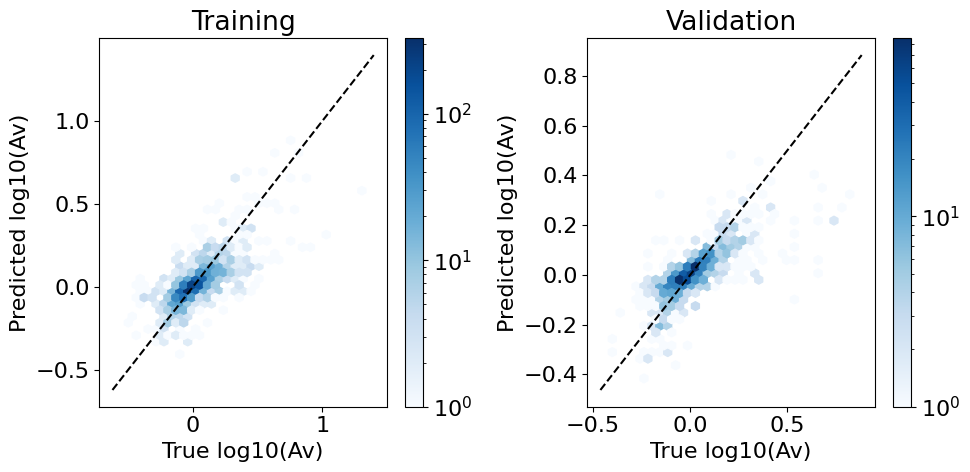

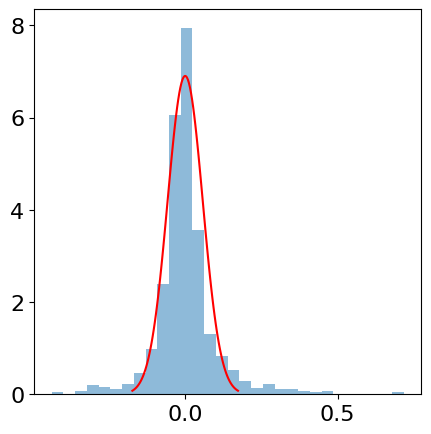

In [57]:
ini_file = 'conf/B1_9.ini'
length = 14

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

b = [0.005426, 0.032420166031911, 25.127016, 2.44034, 0.009374, 1.942815]
c = np.empty(5)
c[:3] = b[1:4]
c[3] = b[4] / np.log(10)
c[4] = b[5]
print(c)

def mypred(c, data=df):
    f = data['dust_mixture']
    Zgas = data['Zgas']
    Av = data['Av']
    sini = data['inclination_sin']
    log10Mstar = data['logMstar']   
    pred = c[0] / Av * ((c[1] * Zgas)**(c[2] * sini) - c[3] * log10Mstar / np.log10(c[4] * f))
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5, 5))
residual = df['true'] - mypred(cnew, data=df)
sigma = (np.percentile(residual, 84) - np.percentile(residual, 16)) / 2
ax.hist(residual, bins=30, alpha=0.5, density=True)
x = np.linspace(-3*sigma, 3*sigma, 100)
y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, y, 'r-')
print('Standard deviation of residuals: %.3f' % sigma)

# $B_2$

Searching for a function of other fit parameters specific to a given dust mixture

## MW dust


Reading from configuration file: conf/B2_3.ini
Reading from selection file: conf/selection_2.ini

All model lengths:
[ 5  7  9 10 11 12 13 15 17 19 20 21 22 23]

Equation requested:
((-0.114305) + (1.247774 * ((0.497712 ^ ((0.167332 * X3) ^ (10.220720 * X2))) * (((-6.420264) * X2) + ((2.757157 * X4) ^ ((-0.131154) * X3))))))


  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:01<00:00,  7.18it/s]



Latex version:
b_{0} b_{1}^{\left(B_{3} b_{2}\right)^{B_{1s} b_{3}}} \left(- B_{1s} b_{4} + \left(A_{V} b_{5}\right)^{- B_{3} b_{6}}\right) - b_{7}

Number of parameters: 8
Values: [1.247774, 0.497712, 0.167332, 10.22072, 6.420264, 2.757157, 0.131154, 0.114305]

1 - R2 for chosen model:
Training: 0.5882
Validation: 0.6227

R2 for chosen model:
Training: 0.4118
Validation: 0.3773


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

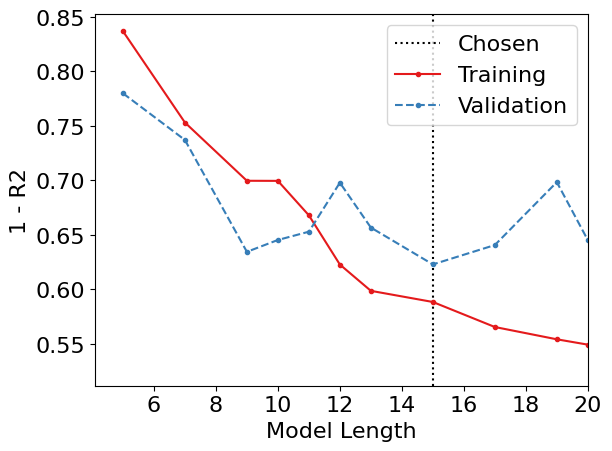

In [15]:
ini_file = 'conf/B2_0.ini'; ilen = 15
ini_file = 'conf/B2_3.ini'; ilen = 15

# These runs don't depend on B0
# ini_file = 'conf/B2_6.ini'; ilen = 15
# ini_file = 'conf/B2_9.ini'; ilen = 15

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## SMC dust


Reading from configuration file: conf/B2_10.ini
Reading from selection file: conf/selection_6.ini

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 19 21 23]

Equation requested:
((-0.398182) + ((-3.260219) * ((0.114272 * X2) ^ log((35.698448 * X3)))))


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 106.65it/s]



Latex version:
- b_{0} \left(B_{3} b_{1}\right)^{\log{\left(A_{V} b_{2} \right)}} - b_{3}

Number of parameters: 4
Values: [3.260219, 0.114272, 35.698448, 0.398182]

1 - R2 for chosen model:
Training: 0.5440
Validation: 0.8130

R2 for chosen model:
Training: 0.4560
Validation: 0.1870


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

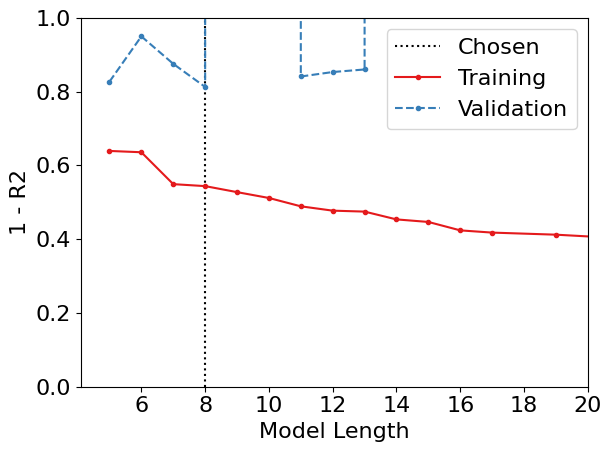

In [18]:
ini_file = 'conf/B2_1.ini'; ilen = 8
ini_file = 'conf/B2_4.ini'; ilen = 8

# These runs don't depend on B0
ini_file = 'conf/B2_7.ini'; ilen = 13
ini_file = 'conf/B2_10.ini'; ilen = 8

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## Stellar dust


Reading from configuration file: conf/B2_11.ini
Reading from selection file: conf/selection_7.ini

All model lengths:
[ 5  7  9 11 13 15 17 18 20 21 23 24]

Equation requested:
(0.128833 + (17853.462891 * (((-0.000012) * X1) / (((((-1.503276) * X1) - ((-0.360355) * X2)) ^ (62.375168 * X1)) - ((-0.019845) * X2)))))


100%|██████████| 12/12 [00:00<00:00, 143.07it/s]


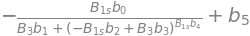


Latex version:
- \frac{B_{1s} b_{0}}{B_{3} b_{1} + \left(- B_{1s} b_{2} + B_{3} b_{3}\right)^{B_{1s} b_{4}}} + b_{5}

Number of parameters: 6
Values: [0.214241554692, 0.019845, 1.503276, 0.360355, 62.375168, 0.128833]

1 - R2 for chosen model:
Training: 0.6094
Validation: 0.6055

R2 for chosen model:
Training: 0.3906
Validation: 0.3945


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

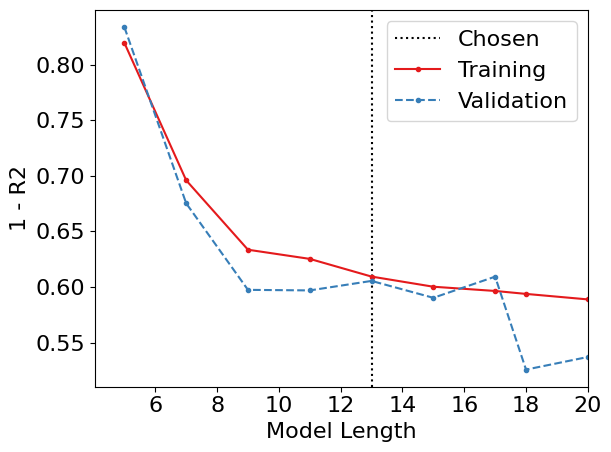

In [23]:
ini_file = 'conf/B2_2.ini'; ilen = 18
ini_file = 'conf/B2_5.ini'; ilen = 15

# These runs don't depend on B0
ini_file = 'conf/B2_8.ini'; ilen = 9
ini_file = 'conf/B2_11.ini'; ilen = 13

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## Mixed dust


Reading from configuration file: conf/B2_15.ini
Reading from selection file: conf/selection_14.ini

All model lengths:
[ 5  6  7  9 10 11 12 14 16 17 18 19 20 21 22 23 24]

Equation requested:
(0.127548 + (0.789495 * ((0.334057 * X2) - ((((log((178.039185 * X2)) - ((-13.455746) * X3)) * (2.302585 * X3)) + ((242.944946 * X2) ^ (-0.779667))) * (0.311232 * X1)))))


100%|██████████| 17/17 [00:00<00:00, 151.35it/s]


Latex version:
B_{0} b_{0} - b_{1} dust_{mixture} \left(B_{1s} b_{4} \left(B_{1s} b_{5} + \log{\left(B_{0} b_{6} \right)}\right) + B_{0}^{- b_{3}} b_{2}\right) + b_{7}

Number of parameters: 8
Values: [0.263736331215, 0.24571610784, 0.0138069653971452, 0.779667, 2.302585, 13.455746, 178.039185, 0.127548]

1 - R2 for chosen model:
Training: 0.2569
Validation: 0.1905

R2 for chosen model:
Training: 0.7431
Validation: 0.8095

Reading from configuration file: conf/B2_15.ini
Reading from selection file: conf/selection_14.ini
fits/B_2s_15/B_2s_train_18.csv
True range: -7.625267 4.590007
fits/B_2s_15/B_2s_val_18.csv
True range: -7.67401 3.393254


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'B_2s: Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'B_2s: Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

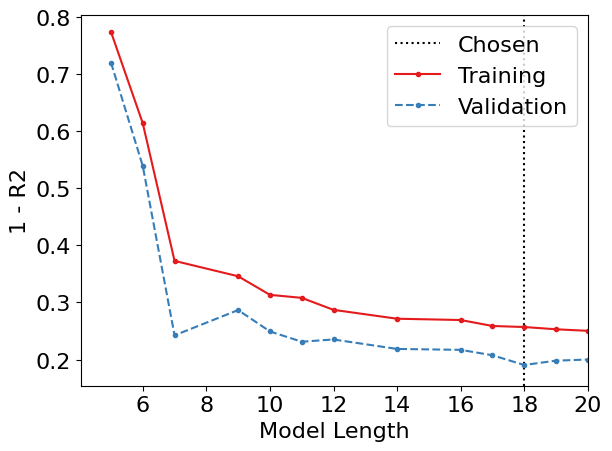

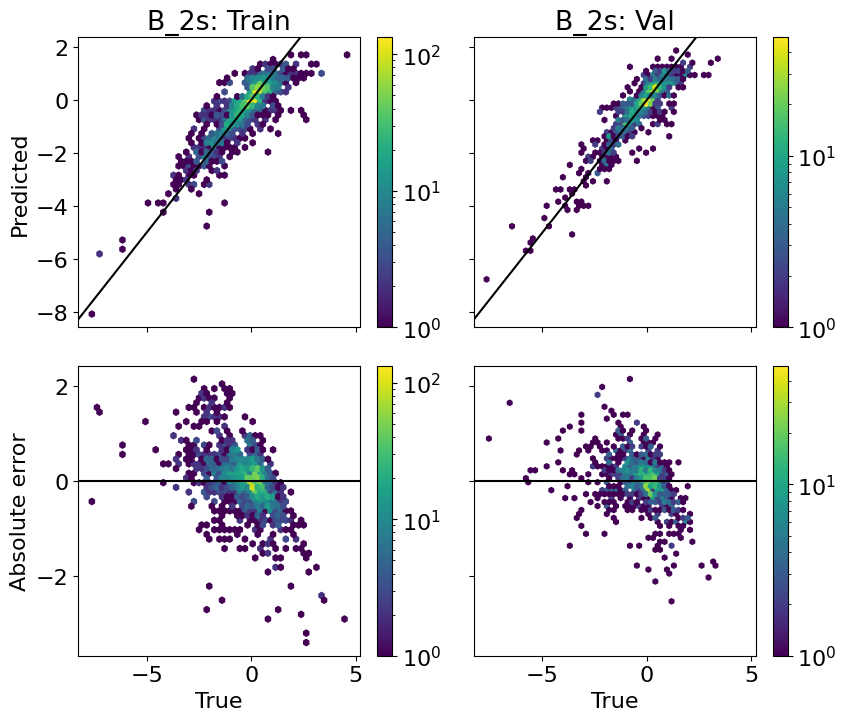

In [ ]:
# These runs do depend on B0
ini_file = 'conf/B2_12.ini'; ilen = 9
# ini_file = 'conf/B2_13.ini'; ilen = 9
# ini_file = 'conf/B2_14.ini'; ilen = 11
ini_file = 'conf/B2_15.ini'; ilen = 18

# These runs don't depend on B0
# ini_file = 'conf/B2_16.ini'; ilen = 17
# ini_file = 'conf/B2_17.ini'; ilen = 19

# B2_15, ilen=18
# Training: 0.7431
# Validation: 0.8095

# B2_16, ilen=17
# Training: 0.6628
# Validation: 0.7101

# B2_17, ilen = 19
# Training: 0.6740
# Validation: 0.7416

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False, log_target=False)


Reading from configuration file: conf/B2_15.ini
Reading from selection file: conf/selection_14.ini
fits/B_2s_15/B_2s_train_18.csv
fits/B_2s_15/B_2s_15_names.txt
['dust_mixture', 'B_0', 'B_1s', 'B_3', 'Av', 'true', 'pred']
(2000, 7)
[2.63736331e-01 1.27548000e-01 3.39259380e-03 7.79667000e-01
 1.30276172e+00 5.84375624e+00 1.78039185e+02]
Initial R2: 0.7430532247962801


True
[2.64421257e-01 1.29107877e-01 3.50799736e-03 7.75837760e-01
 1.28764368e+00 5.93175227e+00 1.78697366e+02]
Final R2: 0.7430595759062809
[0.264, 0.129, 0.00351, 0.776, 1.29, 5.93, 179.0]
Rounded R2 (train): 0.743
Rounded R2 (validation): 0.809
Standard deviation of residuals: 0.381


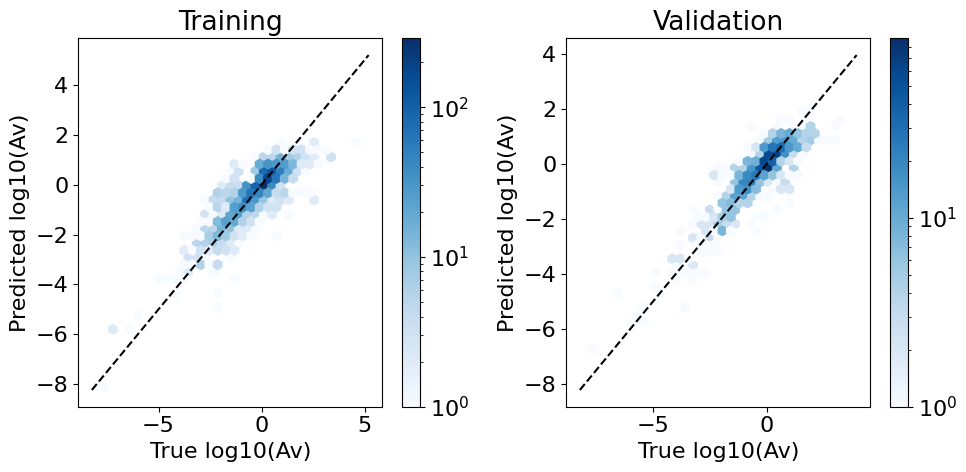

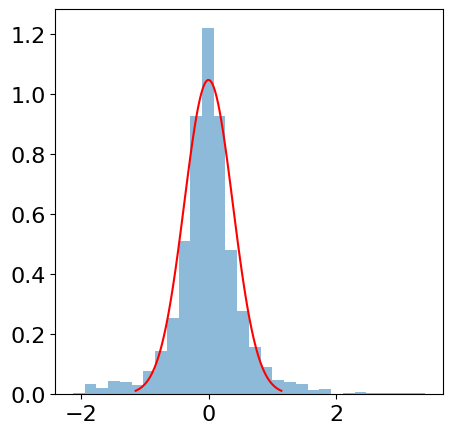

In [58]:
ini_file = 'conf/B2_15.ini'
length = 18

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

b = [0.263736331215, 0.24571610784, 0.0138069653971452, 0.779667, 2.302585, 13.455746, 178.039185, 0.127548]
c = np.empty(7)
c[0] = b[0]
c[1] = b[7]
c[2] = b[1] * b[2]
c[3] = b[3]
c[4] = b[1] * b[4] * np.log(10)
c[5] = b[5] / np.log(10)
c[6] = b[6]
print(c)

def mypred(c, data=df):
    B1s = data['B_1s']
    B0 = data['B_0']
    f = data['dust_mixture']
    pred = c[0] * B0 + c[1] - f * (c[2] * B0**(-c[3]) + c[4] * B1s * (c[5] * B1s + np.log10(c[6] * B0)))
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5, 5))
residual = df['true'] - mypred(cnew, data=df)
sigma = (np.percentile(residual, 84) - np.percentile(residual, 16)) / 2
ax.hist(residual, bins=30, alpha=0.5, density=True)
x = np.linspace(-3*sigma, 3*sigma, 100)
y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, y, 'r-')
print('Standard deviation of residuals: %.3f' % sigma)

# $B_3$

Searching for a function of galaxy properties and $A_{\rm V}$ which is agnostic to dust mixture


Reading from configuration file: conf/B3_13.ini
Reading from selection file: conf/selection_24.ini

All model lengths:
[ 5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
(0.537521 + (1.091852 * ((((0.020406 * X9) ^ ((-0.303942) * X1)) - (((-47.469631) * X5) * ((20.261507 * X9) ^ ((-0.974744) * X8)))) + ((-0.712192) * X10))))


100%|██████████| 19/19 [00:00<00:00, 167.99it/s]



Latex version:
Z_{gas} b_{0} \left(A_{V} b_{1}\right)^{- b_{2} sSFR} - b_{3} \sin{\left(i \right)} + b_{4} + b_{5} \left(A_{V} b_{6}\right)^{- b_{7} f}

Number of parameters: 8
Values: [51.829811546612, 20.261507, 0.974744, 0.777608259584, 0.537521, 1.091852, 0.020406, 0.303942]

1 - R2 for chosen model:
Training: 0.3105
Validation: 0.2542

R2 for chosen model:
Training: 0.6895
Validation: 0.7458

Reading from configuration file: conf/B3_13.ini
Reading from selection file: conf/selection_24.ini
fits/B_3_13/B_3_train_15.csv
True range: 0.163801 6.887024
fits/B_3_13/B_3_val_15.csv
True range: 0.22758 6.660887


(<Figure size 900x750 with 8 Axes>,
 array([[<Axes: title={'center': 'B_3: Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'B_3: Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

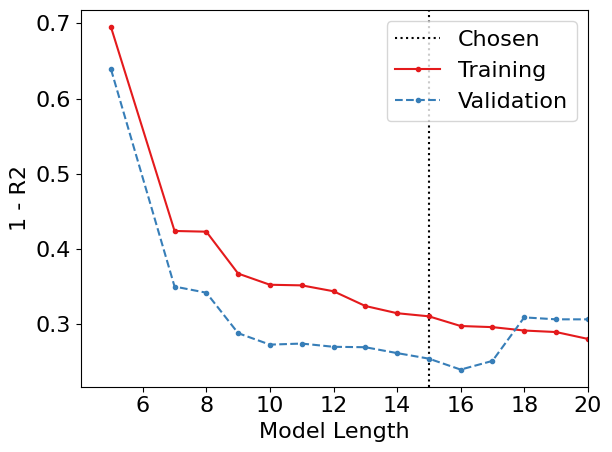

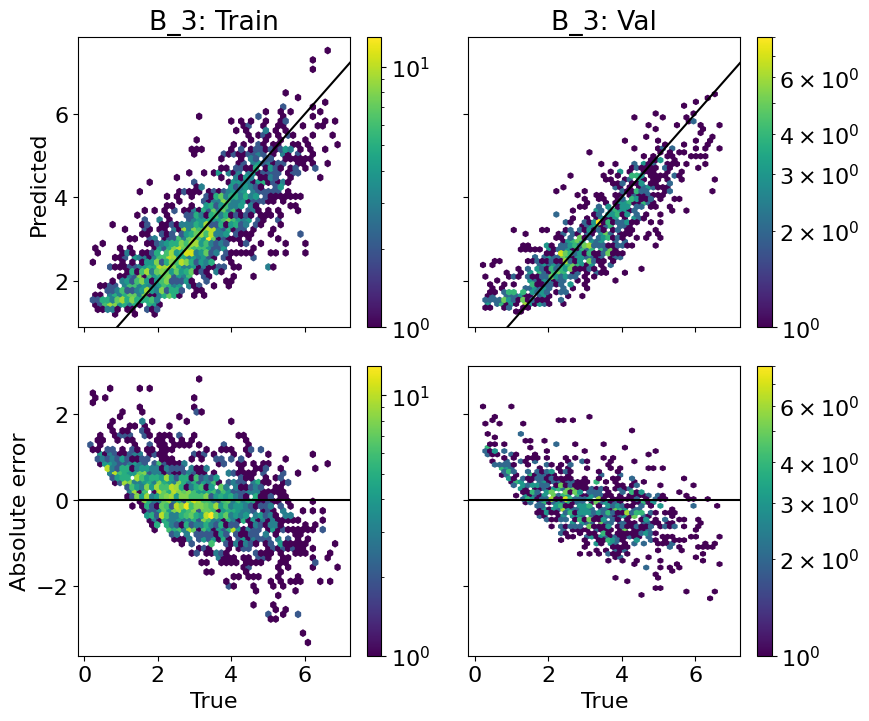

In [29]:
# --------------------------------------------------------
# These models include SFR_compact as a feature

ini_file = 'conf/B3_0.ini'; ilen = 13
ini_file = 'conf/B3_1.ini'; ilen = 14
ini_file = 'conf/B3_2.ini'; ilen = 11

# --------------------------------------------------------
# These models do not include SFR_compact as a feature

# ini_file = 'conf/B3_3.ini'; ilen = 9 # 12
# ini_file = 'conf/B3_4.ini'; ilen = 13
# ini_file = 'conf/B3_5.ini'; ilen = 13

# Currently B3_3 with ilen = 9, 10, or 11 seem ok

# --------------------------------------------------------
# These models do not include SFR_compact as a feature
# and depend on dust mixture parameters

ini_file = 'conf/B3_6.ini'; ilen = 13
# ini_file = 'conf/B3_7.ini'; ilen = 13

# B3_6; ilen=13
# Training: 0.6625
# Validation: 0.7501

# B3_7; ilen=13
# Training: 0.6716
# Validation: 0.7441

# I think B3_6, ilen=13 is a nicer equation than that from B3_7

# --------------------------------------------------------
# These models do not include SFR_compact, Mdust or Mgas as a feature
# and depend on dust mixture parameters
ini_file = 'conf/B3_8.ini'; ilen = 14
ini_file = 'conf/B3_9.ini'; ilen = 16

# --------------------------------------------------------
# Additionally remove Rgas
ini_file = 'conf/B3_10.ini'; ilen = 9
ini_file = 'conf/B3_11.ini'; ilen = 10

# --------------------------------------------------------
# Correct sSFR (cp of 9, 10)
ini_file = 'conf/B3_12.ini'; ilen = 16
ini_file = 'conf/B3_13.ini'; ilen = 15

# B3_10; ilen=9
# Training: 0.6474
# Validation: 0.7270

# B3_11; ilen=10
# Training: 0.6475
# Validation: 0.7272

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)


Reading from configuration file: conf/B3_6.ini
Reading from selection file: conf/selection_17.ini
fits/B_3_6/B_3_train_13.csv
fits/B_3_6/B_3_6_names.txt
['dust_mixture', 'galaxy_id_prop', 'logMstar', 'logMgas', 'SFR', 'Zgas', 'Rstar', 'Rgas', 'logMdust', 'Sigma_SFR', 'sSFR', 'Av', 'inclination_sin', 'true', 'pred']
(2000, 15)
[4.11616933 0.559148   1.16703893 5.189554   1.45892    0.71777112]
Initial R2: 0.6624969616608227
True
[4.11226254 0.56716681 1.15014689 5.24762072 1.45835672 0.71306058]
Final R2: 0.6625119175329097
[4.11, 0.567, 1.15, 5.25, 1.46, 0.713]
Rounded R2 (train): 0.663
Rounded R2 (validation): 0.750
Standard deviation of residuals: 0.762


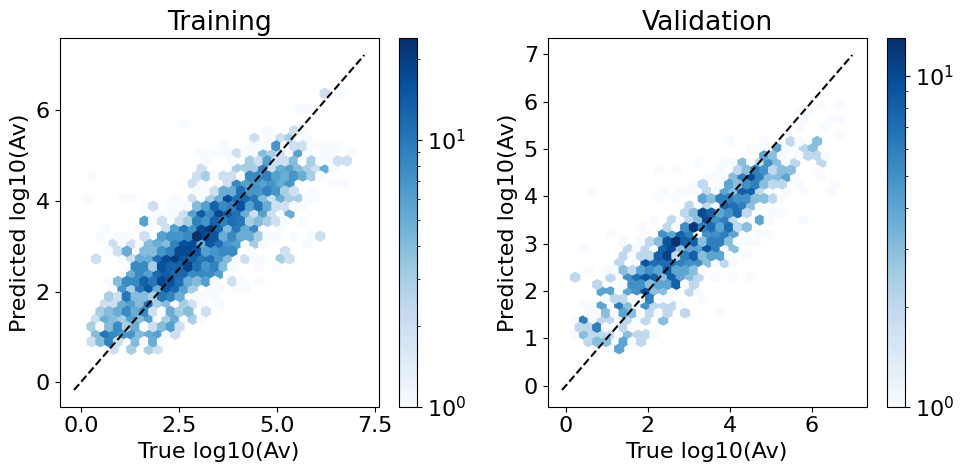

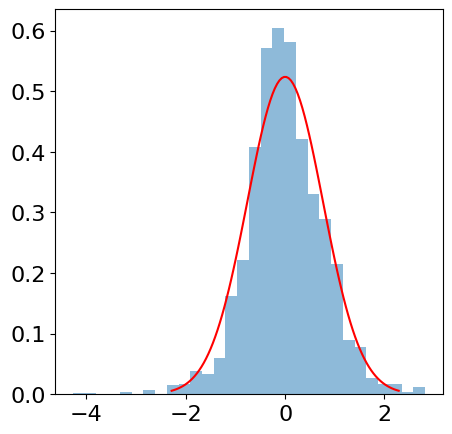

In [56]:
ini_file = 'conf/B3_6.ini'
length = 13

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

b = [4.11616932978, 0.967228, 5.189554, 1.45892, 0.866049, 1.206581, 0.559148]
c = np.empty(6)
c[0] = b[0]
c[1] = b[6]
c[2] = b[1] * b[5]
c[3] = b[2]
c[4] = b[3]
c[5] = b[4] / b[5]
print(c)

def mypred(c, data=df):
    f = data['dust_mixture']
    Zgas = data['Zgas']
    Av = data['Av']
    log10Mstar = data['logMstar']
    log10Mgas = data['logMgas']   
    pred = c[0] * f - c[1] + c[2] * (c[3] * Zgas) ** (c[4] * Av) * (log10Mstar - c[5] * log10Mgas) 
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5, 5))
residual = df['true'] - mypred(cnew, data=df)
sigma = np.std(residual)
ax.hist(residual, bins=30, alpha=0.5, density=True)
x = np.linspace(-3*sigma, 3*sigma, 100)
y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, y, 'r-')
print('Standard deviation of residuals: %.3f' % sigma)


Reading from configuration file: conf/B3_11.ini
Reading from selection file: conf/selection_24.ini
fits/B_3_11/B_3_train_10.csv
fits/B_3_11/B_3_11_names.txt
['dust_mixture', 'galaxy_id_prop', 'logMstar', 'SFR', 'Zgas', 'Rstar', 'Sigma_SFR', 'sSFR', 'Av', 'inclination_sin', 'true', 'pred']
(2000, 12)
[28.87765166  2.85385367  0.154995    0.035206  ]
Initial R2: 0.6475418260889968
True
[28.86893382  2.85406128  0.15499885  0.03507806]
Final R2: 0.6475418341480637
[28.9, 2.85, 0.155, 0.0351]
Rounded R2 (train): 0.648
Rounded R2 (validation): 0.727
Standard deviation of residuals: 0.779


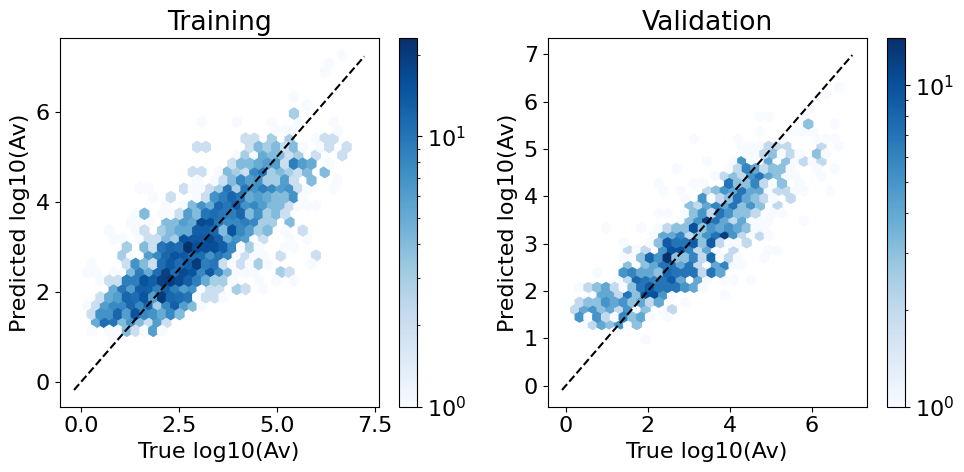

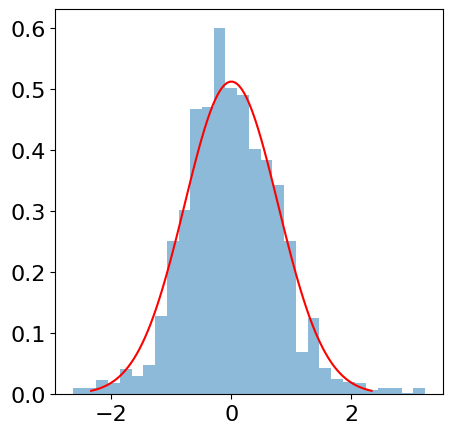

In [26]:
ini_file = 'conf/B3_11.ini'
length = 10

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

b = [0.979605, 12.802512, 1.265217, 0.154995, 0.035206]
c = np.empty(4)
c[0] = b[0] * b[1] * np.log(10)
c[1] = b[0] * b[2] * np.log(10)
c[2:] = b[3:]
print(c)

def mypred(c, data=df):
    f = data['dust_mixture']
    Zgas = data['Zgas']
    Av = data['Av']
    pred = - (c[0] * Zgas + c[1] * f) * np.log10(c[2] * Av) - c[3] 
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5, 5))
residual = df['true'] - mypred(cnew, data=df)
sigma = np.std(residual)
ax.hist(residual, bins=30, alpha=0.5, density=True)
x = np.linspace(-3*sigma, 3*sigma, 100)
y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, y, 'r-')
print('Standard deviation of residuals: %.3f' % sigma)


Reading from configuration file: conf/B3_13.ini
Reading from selection file: conf/selection_24.ini
fits/B_3_13/B_3_train_15.csv
fits/B_3_13/B_3_13_names.txt
['dust_mixture', 'galaxy_id_prop', 'logMstar', 'SFR', 'Zgas', 'Rstar', 'Sigma_SFR', 'sSFR', 'Av', 'inclination_sin', 'true', 'pred']
(2000, 12)
[5.37521000e-01 7.77608260e-01 5.18298115e+01 2.02615070e+01
 9.74744000e-01 1.09185200e+00 2.04060000e-02 3.03942000e-01]
Initial R2: 0.6895267829654076


False
[-2.10163033e+00  8.29638887e-01  5.11059909e+01  2.12209592e+01
  9.70393206e-01  3.51851779e+00  4.16611834e-02  1.70072110e-01]
Final R2: 0.6920629973437449
[-2.1, 0.83, 51.1, 21.2, 0.97, 3.52, 0.0417, 0.17]
Rounded R2 (train): 0.692
Rounded R2 (validation): 0.750
Standard deviation of residuals: 0.728


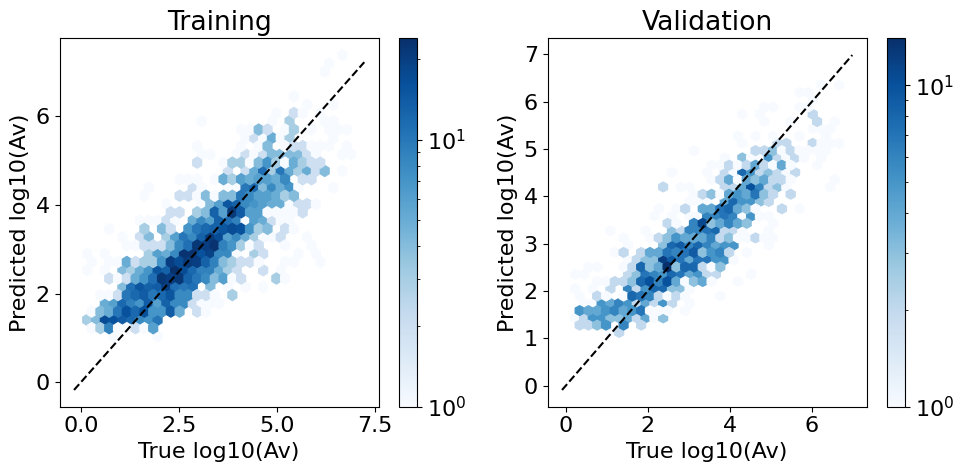

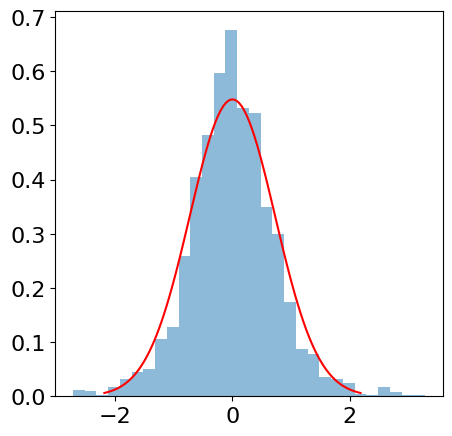

In [37]:
ini_file = 'conf/B3_13.ini'
length = 15

args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
print(f'{out_dir}/{run_name}_names.txt')
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
print(names)
df = pd.read_csv(fname, names=names, sep=r'\s+')
print(df.shape)

fname = pjoin(out_dir, f'{args.target_name}_val_{length}.csv')
df_val = pd.read_csv(fname, names=names, sep=r'\s+')

b = [51.829811546612, 20.261507, 0.974744, 0.777608259584, 0.537521, 1.091852, 0.020406, 0.303942]
c = np.zeros(8)
c[0] = b[4]
c[1] = b[3]
c[2:5] = b[:3]
c[5:] = b[5:]
print(c)

def mypred(c, data=df):
    f = data['dust_mixture']
    Zgas = data['Zgas']
    Av = data['Av']
    sini = data['inclination_sin']
    sSFR = data['sSFR'] 
    pred = c[0] - c[1] * sini + c[2] * Zgas * (c[3] * Av) ** (- c[4] * sSFR) + c[5] * (c[6] * Av) ** (-c[7] * f)
    return pred

def to_opt(c, data=df):
    pred = mypred(c, data=data)
    R2 = 1 - np.sum((data['true'] - pred) ** 2) / np.sum((data['true'] - np.mean(data['true'])) ** 2)
    return -R2

print('Initial R2:', -to_opt(c))
res = minimize(to_opt, c, method='Nelder-Mead')
print(res.success)
print(res.x)
print('Final R2:', -to_opt(res.x))

# Round all parameters to 3 significant figures
cnew = round_sigfigs(np.array(res.x), 3)
print([float(x) for x in cnew])
print('Rounded R2 (train): %.3f'%(-to_opt(cnew)))
print('Rounded R2 (validation): %.3f'%(-to_opt(cnew, data=df_val)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
pred = mypred(cnew, data=df)
hb = axs[0].hexbin(df['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[0])
pred = mypred(cnew, data=df_val)
hb = axs[1].hexbin(df_val['true'], pred, gridsize=30, cmap='Blues', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=axs[1])
for ax in axs:
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, 'k--')
    ax.set_xlabel('True log10(Av)')
    ax.set_ylabel('Predicted log10(Av)')
axs[0].set_title('Training')
axs[1].set_title('Validation')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5, 5))
residual = df['true'] - mypred(cnew, data=df)
sigma = np.std(residual)
ax.hist(residual, bins=30, alpha=0.5, density=True)
x = np.linspace(-3*sigma, 3*sigma, 100)
y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, y, 'r-')
print('Standard deviation of residuals: %.3f' % sigma)